In [12]:
import numpy as np
import sys
sys.path.insert(0, '../src/')
sys.path.insert(0, '../../data-visualization-and-optimisation/DataExploration/')
import useful_functions as uf
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import pandas as pd
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from Perceptron import Perceptron
from VariableNet import VariableNet
from OneLayer import OneLayer
from TwoLayers import TwoLayers
from ThreeLayers import ThreeLayers
from FourLayers import FourLayers
from torch_utils import train_model, save_model, load_model, predictions
from utils import plot_results, cfm, filename, prediction_plots, prepareUnknown, QScanht,  plot  
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from gwpy.timeseries import TimeSeries
import seaborn as sns
torch.set_printoptions(sci_mode=False)
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 500)
from urllib.error import HTTPError
from matplotlib.colors import LinearSegmentedColormap
import nds2
from scipy.spatial import ConvexHull
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
!ls /home/melissa.lopez/GlitchBank/LargeAnalysis/O3aGB/NoGlitcCSV/

ls: cannot access /home/melissa.lopez/GlitchBank/LargeAnalysis/O3aGB/NoGlitcCSV/: No such file or directory


## Define functions

In [3]:
def prepareKnown(tw, ifo, run):
    path_known = '/data/gravwav/lopezm/Projects/GlitchBank/new_boostrapped/tw'+str(tw)+'/'
    data_known = 'dataset_all_'+ifo+'_bootstrap_'+run+'.npy'
    data = np.load(path_known + data_known)
    df = pd.DataFrame(data, columns=['SNR', 'Chisq', 'Mass_1', 'Mass_2', 'Spin1z', 'Spin2z', 'Class'])
    return data[:, :-1], df

In [4]:
def prepareUnknown(tw, ifo):
    path_unknown = '/data/gravwav/lopezm/Projects/GlitchBank/unknown_data/'
    data_unknown = 'features_unknown_'+ifo+'_'+str(tw)+'.csv'
    times_unknown = 'times_unknown_'+ifo+'_'+str(tw)+'.csv'
    du = pd.read_csv(path_unknown + data_unknown)
    du = du.loc[:, ~du.columns.str.match('Unnamed')]
    dt = pd.read_csv(path_unknown + times_unknown)
    dt = dt.loc[:, ~dt.columns.str.match('Unnamed')]
    dt.columns = ['Cluster ID', 'Cluster time']
    display(du)
    data = du
    gpstimes = dt
    
    data_ = data.to_numpy()
    
    return data_, data, gpstimes

In [5]:
def QScanht(start, end, ifo):
    scratch = 2
    srate = 4096.
    background = TimeSeries.fetch_open_data(ifo,
                                            start-1,
                                            end+1,
                                            sample_rate=srate)
    #print(background.times[0] - background.times[-1])
    q_scan = background.q_transform(qrange=[4,64], frange=[10, 2048],
                              tres=0.002, fres=0.5, whiten=True)
    return q_scan

    
def plotCluster(template_bank, df_group, q_scan, start, end, ifo, gw190521=False):
    c = 'tomato'
    tmp_time = np.unique(df_group['Cluster time'])[0]
    fig, (ax1, ax2)  = plt.subplots(2, 1,dpi=120)
    ax1.scatter(df_group['Trigger time'], df_group['SNR'], label='Cluster')
    ax1.scatter(min(df_group['Trigger time']), df_group['SNR'].iloc[np.argmin(df_group['Trigger time'])], label=r'$t_{min}$', c='tomato')
    ax1.scatter(max(df_group['Trigger time']), df_group['SNR'].iloc[np.argmax(df_group['Trigger time'])], label=r'$t_{max}$', c='orchid')
    ax1.axvline(tmp_time, c='crimson', label=r'$t_{cluster}$')
    t_gw190521 = 1242442967.4
    if gw190521 and (t_gw190521 > min(q_scan.times).value) and (t_gw190521 < max(q_scan.times).value):
        ax1.axvline(t_gw190521, c='black', label=r'$GW190521$', linewidth=1, alpha=0.8)
    ax1.legend(bbox_to_anchor=(1, 0.9))
    ax1.set_xlim(min(q_scan.times).value, max(q_scan.times).value)
    ax1.xaxis.set_major_formatter(ScalarFormatter())
    ax1.set_ylabel('SNR')

    #print(start, end, tmp_time)
    ax2.imshow(q_scan[100:-100], cmap='viridis')
    ax2.set_yscale('log', base=2)
    ax2.set_xscale('linear')
    ax2.set_ylabel('Frequency (Hz)', fontsize=14)
    ax2.set_xlabel('Time (s)', labelpad=0.1,  fontsize=14)
    ax2.yaxis.set_major_formatter(ScalarFormatter())
    ax2.tick_params(axis ='both', which ='major', labelsize = 14)
    ax2.axvline(start, c='tomato', label=r'$t_{min}$', linewidth=1, alpha=0.8)
    ax2.axvline(end, c='orchid', label=r'$t_{max}$', linewidth=1, alpha=0.8)
    ax2.axvline(tmp_time, c='crimson', label=r'$t_{cluster}$', linewidth=1, alpha=0.8)
    cb = ax2.colorbar(label='Normalized energy',clim=[0, 25.5])
    if gw190521:
        ax2.axvline(1242442967.4, c='black', label=r'$GW190521$', linewidth=1, alpha=0.8)
    #ax2.legend(bbox_to_anchor=(0.5, 1.2), ncol=3)
    plt.tight_layout()
    plt.savefig('specGW190521_'+ifo+'.pdf',
            format="pdf", bbox_inches="tight", rasterized=True)
    
    cmap = LinearSegmentedColormap.from_list(name='test', colors=['plum', 'darkslateblue'])
    display(df_group['Mass_1'])
    fig, ax = plt.subplots(figsize=(12,6))
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xticks(ticks=[50,60, 80,100,150, 200, 300, 400])
    ax.set_yticks(ticks=[9,20, 40, 80, 100,150, 200, 300, 380])
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    ax.get_yaxis().set_major_formatter(ScalarFormatter())
    ax.set_xlabel('$log(m_1)$',fontsize=14); ax.set_ylabel('$log(m_2)$',fontsize=14); 
    ax.scatter(template_bank['Mass_1'],template_bank['Mass_2'], color='silver', s=3,alpha=0.4)
    im = ax.scatter(df_group['Mass_1'], df_group['Mass_2'], s=20, cmap=cmap,
                    #c=df_group['Trigger time'] - df_group['Cluster time'])
                    c=df_group['SNR'])
    cgl = fig.colorbar(im, ax=ax)
    cgl.ax.set_ylabel(r'$\rho$', fontsize=14)
    plt.savefig('triggersGW190521_'+ifo+'.pdf',
            format="pdf", bbox_inches="tight", rasterized=True)
    
def clusterPlot(t_star, ifo, template_bank):
    c, c_time = getChunk(t_star)
    tw = 0.05
    path = '/home/melissa.lopez/GlitchBank/LargeAnalysis/O3aGB/NoGlitcCSV/tw'+str(tw)+'/'
    dt = pd.read_csv(path +'alltrigs_noglitch_cluster_'+ifo+'_chunk'+str(c)+'.csv')
    dt = dt.sort_values(by='Cluster time')

    dt_ = dt.groupby(['Cluster ID', 'Cluster time'])
    for group_name, dt_group in dt_:

        if len(dt_group['Trigger time']) == 1:
            start = dt_group['Trigger time'].values[0]
            end = dt_group['Trigger time'].values[0]
        else:
            start = min(dt_group['Trigger time'])
            end = max(dt_group['Trigger time'])
        tmp_time = np.unique(dt_group['Cluster time'])[0]

        #print(tmp_time - 1242442967.4)
        if (tmp_time  > t_star - 0.1) and (tmp_time  < t_star + 0.1):
        #if (tmp_time  == t_star):
            tmp_ = dt_group.iloc[np.argmax(dt_group['SNR'])]
            q_scan = QScanht(start, end, ifo)
            plotCluster(template_bank, dt_group, q_scan, start, end, ifo, gw190521=True)


In [6]:
def doubleCoincidence(data1, data2, ifo1, ifo2):
    columns=['SNR_'+ifo1, 'Chisq_'+ifo1, 'Mass_1_'+ifo1, 'Mass_2_'+ifo1, 'Spin1z_'+ifo1, 'Spin2z_'+ifo1, 'Class_'+ifo1, 'Num_triggers_'+ifo1, 'Cluster_ID'+ifo1, 'Cluster_times_'+ifo1, 'ProbInj_'+ifo1, 
             'SNR_'+ifo2, 'Chisq_'+ifo2, 'Mass_1_'+ifo2, 'Mass_2_'+ifo2, 'Spin1z_'+ifo2, 'Spin2z_'+ifo2, 'Class_'+ifo2, 'Num_triggers_'+ifo2, 'Cluster_ID'+ifo2, 'Cluster_times_'+ifo2, 'ProbInj_'+ifo2]
    print(len(columns))
    tmps = list()
    for i in range(len(data1)): 
        tmp1 = data1.iloc[i]
        tmp2 = data2.loc[(data2['Cluster time'] >= tmp1['Cluster time'] - 0.03) & (data2['Cluster time'] <= tmp1['Cluster time'] + 0.03)]

        if len(tmp2) == 1:
            tmps.append(list(tmp1.values)+ list(tmp2.values[0]))

    tmp = pd.DataFrame(tmps, columns=columns)
    return tmp

def tripleCoincidence(data1, data2, data3, ifo1, ifo2, ifo3):
    columns=['SNR_'+ifo1, 'Chisq_'+ifo1, 'Mass_1_'+ifo1, 'Mass_2_'+ifo1, 'Spin1z_'+ifo1, 'Spin2z_'+ifo1, 'Class_'+ifo1, 'Num_triggers_'+ifo1, 'Cluster_ID'+ifo1, 'Cluster_times_'+ifo1, 'ProbInj_'+ifo1, 
             'SNR_'+ifo2, 'Chisq_'+ifo2, 'Mass_1_'+ifo2, 'Mass_2_'+ifo2, 'Spin1z_'+ifo2, 'Spin2z_'+ifo2, 'Class_'+ifo2, 'Num_triggers_'+ifo2, 'Cluster_ID'+ifo2, 'Cluster_times_'+ifo2, 'ProbInj_'+ifo2,
             'SNR_'+ifo3, 'Chisq_'+ifo3, 'Mass_1_'+ifo3, 'Mass_2_'+ifo3, 'Spin1z_'+ifo3, 'Spin2z_'+ifo3, 'Class_'+ifo3, 'Num_triggers_'+ifo3, 'Cluster_ID'+ifo3, 'Cluster_times_'+ifo3, 'ProbInj_'+ifo3]
    print(len(columns))
    tmps = list()
    for i in range(len(data1)): 
        tmp1 = data1.iloc[i]
        tmp2 = data2.loc[(data2['Cluster time'] >= tmp1['Cluster time'] - 0.03) & (data2['Cluster time'] <= tmp1['Cluster time'] + 0.03)]
        tmp3 = data3.loc[(data3['Cluster time'] >= tmp1['Cluster time'] - 0.03) & (data3['Cluster time'] <= tmp1['Cluster time'] + 0.03)]

        if (len(tmp2) == 1) and (len(tmp3) == 1):
            tmps.append(list(tmp1.values)+ list(tmp2.values[0]) + list(tmp3.values[0]))

    tmp = pd.DataFrame(tmps, columns=columns)
    return tmp

In [7]:
def plot_spectrogram(tmp):
    """
    Plots a spectrogram of a given time series.

    Parameters:
        tmp (array-like): Input time series.

    Returns:
        None
    """

    # Perform q-transform
    q_scan = tmp.q_transform(qrange=[4, 64], frange=[10, 2048],
                             tres=0.002, fres=0.5, whiten=True)

    # Plot spectrogram
    fig, ax = plt.subplots(dpi=120)
    ax.imshow(q_scan, cmap='viridis', vmin=0, vmax=25.5)
    ax.set_yscale('log', base=2)
    ax.set_xscale('linear')
    ax.set_ylabel('Frequency (Hz)', fontsize=14)
    ax.set_xlabel('Time (s)', labelpad=0.1, fontsize=14)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.tick_params(axis='both', which='major', labelsize=14)
    #cb = ax.colorbar(label='Normalized energy', clim=[0, 25.5])
    plt.show()

In [8]:
def plotSpecEvent(ifos, times):
    fig, ax = plt.subplots(1, len(ifos), dpi=120)
    for i, ifo, t in zip(np.arange(len(ifos)), ifos, times):
        strain = TimeSeries.fetch_open_data(ifo, t - 1, t + 1)
        # Perform q-transform
        q_scan = strain.q_transform(qrange=[4, 64], frange=[10, 2048],
                                 tres=0.002, fres=0.5, whiten=True)
        # Plot spectrogram
        ax[i].imshow(q_scan, cmap='viridis', vmin=0, vmax=25.5,label=ifo)
        ax[i].set_yscale('log', base=2)
        ax[i].set_xscale('linear')
        ax[0].set_ylabel('Frequency (Hz)', fontsize=14)
        if i !=0:
            ax[i].set_yticks([])
        ax[i].axvline(t, c='crimson', alpha=0.5)
        ax[i].yaxis.set_major_formatter(ScalarFormatter())

    plt.show()
    plt.tight_layout()

In [9]:
def detectedGWOSC(events, t1, df, i):
    gwosc = False
    for e in range(len(events)):

        if int(events.iloc[e]['GPS']) - int(t1) == 0: #FIXME: improve this time window

            print(i, 
                  'GW detected: ',events['commonName'][e],
                  events['catalog.shortName'][e], 
                  df.iloc[i]['Prob0_'+ifo1], df.iloc[i]['Prob0_'+ifo2])
            gwosc = True
    return gwosc

In [10]:
def point_in_hull(point, hull, tolerance=1e-12):
    return all(
        (np.dot(eq[:-1], point) + eq[-1] <= tolerance)
        for eq in hull.equations)

## Check data

### Preliminary

In [7]:
pH1 = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_H1.csv')
pH1 = pH1.loc[:, ~pH1.columns.str.match('Unnamed')]

pL1 = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_L1.csv')
pL1 = pL1.loc[:, ~pL1.columns.str.match('Unnamed')]

pV1 = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_V1.csv')
pV1 = pV1.loc[:, ~pV1.columns.str.match('Unnamed')]

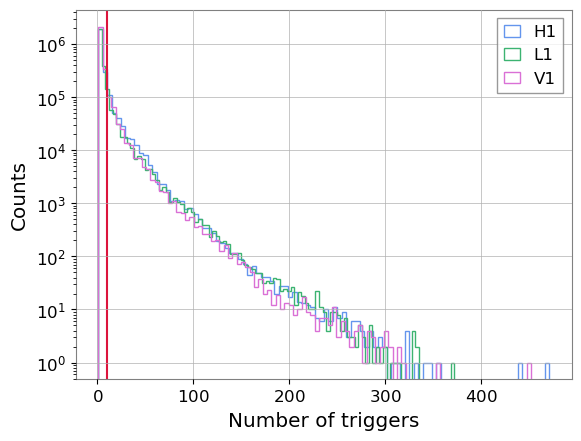

In [17]:
plt.hist(pH1['Num triggers'], bins=100, histtype='step', color='cornflowerblue', label='H1'),
plt.hist(pL1['Num triggers'], bins=100, histtype='step', color='mediumseagreen', label='L1'),
plt.hist(pV1['Num triggers'], bins=100, histtype='step', color='orchid', label='V1'),
plt.axvline(10, c='crimson')
plt.yscale('log')
plt.xlabel('Number of triggers'), plt.ylabel('Counts')
plt.legend()

In [18]:
pH1_ = pH1[(pH1['Cluster time'] > 1242442967.4 -20000) & (pH1['Cluster time'] < 1242442967.4 +20000)]
pL1_ = pL1[(pL1['Cluster time'] > 1242442967.4 -20000) & (pL1['Cluster time'] < 1242442967.4 +20000)]


display(pH1_)
display(pL1_)

,SNR,Chisq,Mass_1,Mass_2,Spin1z,Spin2z,Prob0,Prob1,Prob2,Prob3,Prob4,Prob5,Prob6,Num triggers,Cluster ID,Cluster time
346167,5.504354,1.216764,42.242497,9.939208,0.937476,0.696860,1.082480e-10,1.052800e-10,5.226650e-30,1.936347e-10,0.0,1.000000e+00,0.000000e+00,7,54037.0,1.242423e+09
346168,4.156702,0.996336,45.039787,9.269236,-0.273304,-0.602280,9.999999e-01,1.060037e-08,0.000000e+00,1.124358e-07,0.0,6.075111e-09,4.718191e-23,1,54038.0,1.242423e+09
346169,4.370801,0.962821,45.105320,5.185626,0.918203,0.152546,3.243274e-04,3.456977e-14,3.705483e-34,9.996580e-01,0.0,1.758542e-05,0.000000e+00,1,54039.0,1.242423e+09
346170,4.094262,0.887941,62.461687,8.379415,0.340383,-0.058243,9.721509e-01,7.881263e-13,0.000000e+00,2.784912e-02,0.0,1.761255e-11,6.600000e-44,3,54040.0,1.242423e+09
346171,4.337716,0.571162,74.076344,8.179716,0.907492,-0.452376,9.433743e-01,3.368044e-24,0.000000e+00,5.660635e-02,0.0,1.936235e-05,0.000000e+00,4,54041.0,1.242423e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351203,4.493062,0.820702,86.340820,15.599413,0.169537,0.448864,9.969866e-01,7.596123e-28,0.000000e+00,2.989653e-03,0.0,2.376140e-05,0.000000e+00,1,59073.0,1.242463e+09
351204,4.497471,1.325740,45.466864,5.293616,0.885530,-0.904661,4.592817e-01,4.598828e-06,1.317823e-31,2.879719e-01,0.0,2.527417e-01,0.000000e+00,2,59074.0,1.242463e+09
351205,4.384796,1.203124,47.721353,5.130854,0.839365,0.173528,6.589727e-01,3.154809e-09,9.763908e-31,3.399861e-01,0.0,1.041273e-03,0.000000e+00,4,59075.0,1.242463e+09
351206,4.166672,1.019102,60.245678,8.223622,0.969807,-0.464231,4.066563e-02,5.351950e-08,0.000000e+00,9.593343e-01,0.0,3.583359e-10,0.000000e+00,1,59076.0,1.242463e+09


,SNR,Chisq,Mass_1,Mass_2,Spin1z,Spin2z,Prob0,Prob1,Prob2,Prob3,Prob4,Prob5,Prob6,Num triggers,Cluster ID,Cluster time
393779,5.622396,1.041820,45.487095,4.604047,0.722643,0.365065,0.001476,4.811026e-07,4.598425e-26,1.467105e-05,2.982435e-37,4.012014e-01,5.973077e-01,1,62424.0,1.242423e+09
393780,5.741000,1.699530,45.256087,5.282516,0.529506,-0.498580,0.155460,3.862296e-10,4.039130e-36,8.008645e-06,0.000000e+00,8.369589e-01,7.572788e-03,3,62425.0,1.242423e+09
393781,4.141871,0.843057,42.487926,9.786650,0.930597,0.647409,0.020874,7.528163e-22,1.284175e-27,9.791264e-01,1.058950e-38,3.854459e-26,3.399623e-14,7,62426.0,1.242423e+09
393782,7.115142,1.334111,381.381559,121.817170,0.780623,0.313523,0.673982,0.000000e+00,1.503164e-37,0.000000e+00,7.780454e-15,0.000000e+00,3.260182e-01,10,62427.0,1.242423e+09
393783,4.094980,1.330729,45.105320,5.185626,0.918203,0.152546,1.000000,5.223259e-12,7.893690e-21,9.156301e-13,0.000000e+00,2.573053e-11,2.756405e-15,1,62428.0,1.242423e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398870,4.433145,0.911486,44.128219,6.326831,0.866702,0.155271,0.997979,1.006534e-25,1.060241e-23,1.638180e-12,2.266520e-40,3.329493e-04,1.688237e-03,2,67515.0,1.242463e+09
398871,5.420474,1.058898,86.340820,15.599413,0.169537,0.448864,1.000000,2.488409e-16,2.198141e-32,6.059787e-21,6.573909e-14,7.230000e-43,6.775479e-17,1,67516.0,1.242463e+09
398872,5.408497,1.004455,45.464382,5.293967,0.885566,-0.904601,1.000000,1.450758e-13,0.000000e+00,2.116804e-07,0.000000e+00,3.470595e-10,8.974009e-10,2,67517.0,1.242463e+09
398873,5.678319,0.714589,60.245678,8.223622,0.969807,-0.464231,0.001512,2.442570e-26,0.000000e+00,9.984880e-01,0.000000e+00,5.367314e-19,1.400124e-07,1,67518.0,1.242463e+09


Index(['SNR_H1', 'Chisq_H1', 'Mass_1_H1', 'Mass_2_H1', 'Spin1z_H1',
       'Spin2z_H1', 'Prob0_H1', 'Prob1_H1', 'Prob2_H1', 'Prob3_H1', 'Prob4_H1',
       'Prob5_H1', 'Prob6_H1', 'Num triggers_H1', 'Cluster ID_H1',
       'Cluster time_H1', 'SNR_L1', 'Chisq_L1', 'Mass_1_L1', 'Mass_2_L1',
       'Spin1z_L1', 'Spin2z_L1', 'Prob0_L1', 'Prob1_L1', 'Prob2_L1',
       'Prob3_L1', 'Prob4_L1', 'Prob5_L1', 'Prob6_L1', 'Num triggers_L1',
       'Cluster ID_L1', 'Cluster time_L1'],
      dtype='object')


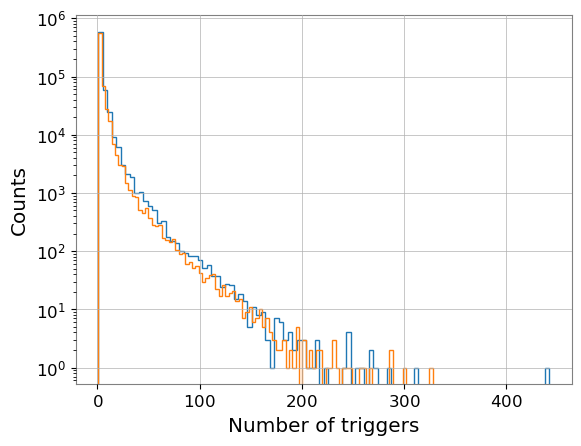

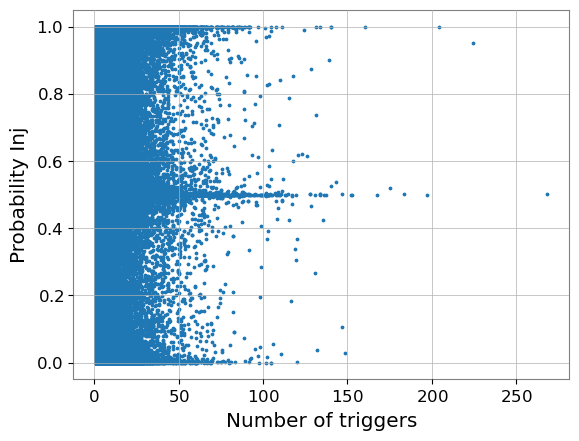

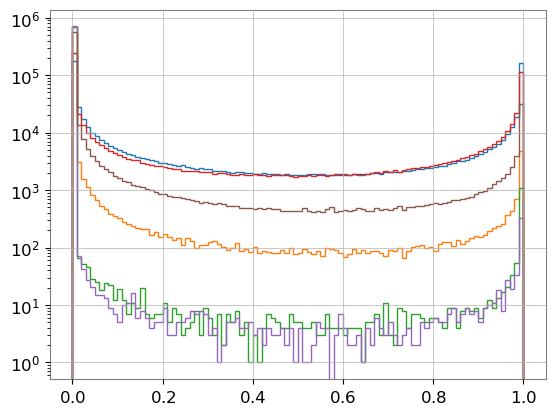

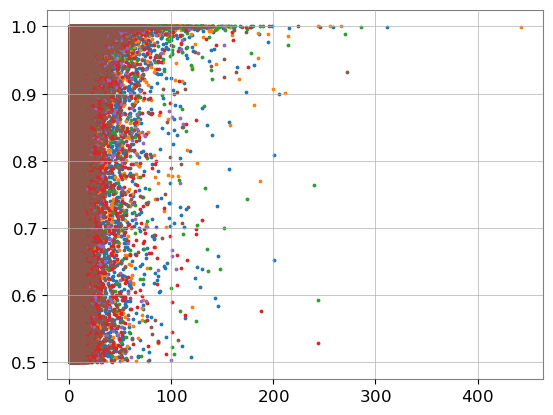

In [112]:
ifos = 'H1L1'
ifo1, ifo2 = ifos[:2], ifos[2:]

df = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_'+ifos+'.csv')
df = df.loc[:, ~df.columns.str.match('Unnamed')]
print(df.columns)
plt.hist(df['Num triggers_'+ifo1],histtype='step', bins=100)
plt.hist(df['Num triggers_'+ifo2],histtype='step', bins=100)
plt.yscale('log')
plt.xlabel('Number of triggers'), plt.ylabel('Counts')
plt.show()

plt.scatter((df['Num triggers_'+ifo1]+df['Num triggers_'+ifo2])/2,
            (df['Prob0_'+ifo1]+df['Prob0_'+ifo2])/2, s=3)
#plt.scatter(df['Num triggers_H1.1'], df['Prob0_H1.1'], s=3)

plt.xlabel('Number of triggers'), plt.ylabel('Probability Inj')
plt.show()

for i in range(6):
    plt.hist(df['Prob'+str(i)+'_'+ifo1],histtype='step', bins=100)
plt.yscale('log')
plt.show()

for i in range(6):
    tmp = df.loc[df['Prob'+str(i)+'_'+ifo1] > 0.5]
    plt.scatter(tmp['Num triggers_'+ifo1], tmp['Prob'+str(i)+'_'+ifo1], s=3)
    
df['Av num triggers'] = (df['Num triggers_'+ifo1]+df['Num triggers_'+ifo2])/2
df = df.sort_values(by='Av num triggers', ascending=False)
df = df.loc[(df['Prob0_'+ifo1]>0.9) & (df['Prob0_'+ifo2]>0.9)]
df = df.loc[(df['Av num triggers']>3)]

### Check for known GW signals

In [11]:
events = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/allevents.csv')

In [10]:
for ifos in ['H1L1', 'H1V1', 'L1V1']:
    ifo1, ifo2 = ifos[:2], ifos[2:]

    df = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_'+ifos+'.csv')
    df = df.loc[:, ~df.columns.str.match('Unnamed')]
    df['Av num triggers'] = (df['Num triggers_'+ifo1]+df['Num triggers_'+ifo2])/2
    df['Av prob0'] = (df['Prob0_'+ifo1]+df['Prob0_'+ifo2])/2
    df = df.sort_values(by='Av num triggers', ascending=False)
    df = df.loc[(df['Av prob0']>0.9)]
    df = df.loc[(df['Av num triggers']>3)]

    gws, catalg_gws = list(), list()
    c = 0
    times1= df['Cluster time_'+ifo1]
    for i in range(len(df)):

        #tmp = df.iloc[i]
        t1 = times1.iloc[i]

        for e in range(len(events)):

            if (int(events.iloc[e]['GPS'])) - int(t1) == 0:
                gws.append(np.asarray(df.iloc[i].values))
                catalg_gws.append(events.iloc[e].values)
                #print(i, 'GW detected: ',events['commonName'][e],events['catalog.shortName'][e], tmp['Prob0_'+ifo1], tmp['Prob0_'+ifo2])
                c = c +1
    gws = pd.DataFrame(gws, columns=df.columns)
    catalg_gws = pd.DataFrame(catalg_gws, columns=events.columns)
    discovert_2coinc = pd.merge(gws, catalg_gws, left_index=True, right_index=True)
    discovert_2coinc = discovert_2coinc.drop_duplicates(subset=['Cluster time_'+ifo1]).reset_index(drop=True)
    discovert_2coinc.to_csv('gw_known_discovert_'+ifos+'.csv')

KeyboardInterrupt: 

In [ ]:
gws = pd.DataFrame(gws, columns=df.columns)
catalg_gws = pd.DataFrame(catalg_gws, columns=events.columns)
discovert_2coinc = pd.merge(gws, catalg_gws, left_index=True, right_index=True)
discovert_2coinc = discovert_2coinc.drop_duplicates(subset=['Cluster time_'+ifo1]).reset_index(drop=True)


### Check results

In [11]:
events = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/allevents.csv')
evetns = events.loc[events['GPS']>1238166018].sort_values(by='GPS')

(45, 45, 45)

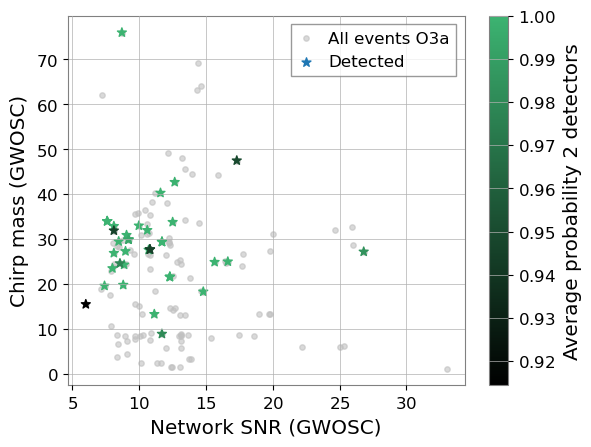

In [172]:
cmap = LinearSegmentedColormap.from_list(
        name='test', 
        colors=['black', 'mediumseagreen'])
plt.scatter(events['network_matched_filter_snr'], events['chirp_mass_source'], s=15, alpha=0.6, c='silver', label='All events O3a')
net_snrs, chirp_mass, probs = list(), list(), list()
for ifos in ['H1L1', 'L1V1', 'H1V1']:
    gw_disc = pd.read_csv('gw_known_discovert_'+ifos+'.csv')
    net_snrs.extend(gw_disc['network_matched_filter_snr'].values)
    chirp_mass.extend(gw_disc['chirp_mass_source'].values)
    probs.extend((gw_disc['Prob0_'+ifos[:2]].values+gw_disc['Prob0_'+ifos[2:]].values)/2)
plt.scatter(net_snrs,chirp_mass, s=45, marker='*',c=probs, cmap=cmap, label='Detected')
plt.colorbar(label='Average probability 2 detectors')
plt.xlabel('Network SNR (GWOSC)')
plt.ylabel('Chirp mass (GWOSC)')
plt.legend()
len(net_snrs), len(chirp_mass), len(probs)

In [38]:
df.columns

Index(['SNR_L1', 'Chisq_L1', 'Mass_1_L1', 'Mass_2_L1', 'Spin1z_L1',
       'Spin2z_L1', 'Prob0_L1', 'Prob1_L1', 'Prob2_L1', 'Prob3_L1', 'Prob4_L1',
       'Prob5_L1', 'Prob6_L1', 'Num triggers_L1', 'Cluster ID_L1',
       'Cluster time_L1', 'SNR_V1', 'Chisq_V1', 'Mass_1_V1', 'Mass_2_V1',
       'Spin1z_V1', 'Spin2z_V1', 'Prob0_V1', 'Prob1_V1', 'Prob2_V1',
       'Prob3_V1', 'Prob4_V1', 'Prob5_V1', 'Num triggers_V1', 'Cluster ID_V1',
       'Cluster time_V1', 'Av num triggers', 'Av prob0'],
      dtype='object')

In [17]:
ifos = 'H1L1'
ifo1, ifo2 = ifos[:2], ifos[2:]
df = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_'+ifos+'.csv')
df = df.loc[:, ~df.columns.str.match('Unnamed')]
df['Av num triggers'] = (df['Num triggers_'+ifo1]+df['Num triggers_'+ifo2])/2
df['Av prob0'] = (df['Prob0_'+ifo1]+df['Prob0_'+ifo2])/2
df = df.sort_values(by=['Num triggers_'+ifo1, 'Num triggers_'+ifo2], ascending=False)
df = df.loc[(df['Av prob0']>0.9)]
df = df.loc[(df['Num triggers_'+ifo1] >= 3) & (df['Num triggers_'+ifo2] > 3)]
m = 5
#df = df.loc[(df['Mass_1_'+ifo2] >= df['Mass_1_'+ifo1] - m) & (df['Mass_1_'+ifo2] <= df['Mass_1_'+ifo1] + m)]
#display(df)

for i in range(20):
    tmp = df.iloc[i]
    t1 = tmp['Cluster time_'+ifo1]
    m1 = tmp['Mass_1_'+ifo1]
    m2 = tmp['Mass_1_'+ifo2]
    
    gwosc = detectedGWOSC(events, t1)

    #if gwosc is False:
    print('SNR',df.iloc[i]['SNR_'+ifo1], df.iloc[i]['SNR_'+ifo2])
    print('mass 1',  df.iloc[i]['Mass_1_'+ifo1], df.iloc[i]['Mass_1_'+ifo2])
    print('num triggers',  df.iloc[i]['Num triggers_'+ifo1], df.iloc[i]['Num triggers_'+ifo2])
    print('cluster time',  df.iloc[i]['Cluster time_'+ifo1], df.iloc[i]['Cluster time_'+ifo2])


    #plotSpecEvent([ifo1, ifo2],
    #              [df.iloc[i]['Cluster time_'+ifo1], df.iloc[i]['Cluster time_'+ifo2]])
    print(' ')


TypeError: detectedGWOSC() missing 2 required positional arguments: 'df' and 'i'

ValueError: Input signal contains non-numerical values

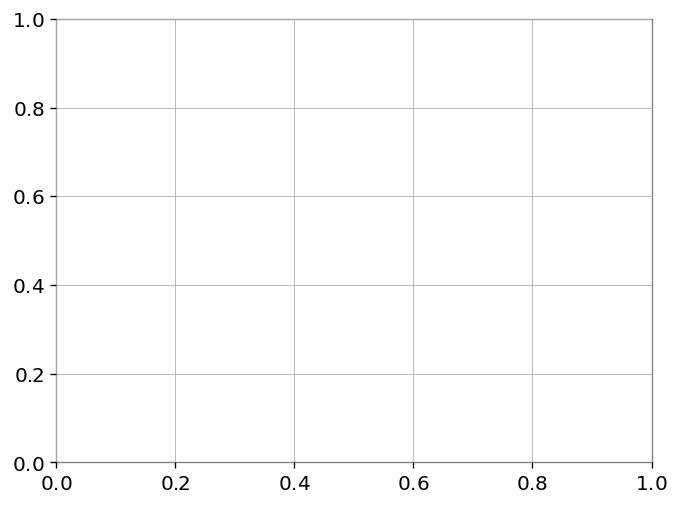

In [163]:
t1 = 1262909226.0602279
fig, ax = plt.subplots(dpi=120)
strain = TimeSeries.fetch_open_data('V1', t1 - 1, t1 + 1)
# Perform q-transform
q_scan = strain.q_transform(qrange=[4, 64], frange=[10, 2048],
                         tres=0.002, fres=0.5, whiten=True)
# Plot spectrogram
ax.imshow(q_scan, cmap='viridis', vmin=0, vmax=25.5)
ax.set_yscale('log', base=2)
ax.set_xscale('linear')
ax.set_ylabel('Frequency (Hz)', fontsize=14)
ax.axvline(t1, c='crimson', alpha=0.5)
ax.yaxis.set_major_formatter(ScalarFormatter())

plt.show()

In [150]:
ifos = 'H1L1V1'
ifo1, ifo2, ifo3 = 'H1', 'L1', 'V1'
df = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_'+ifos+'.csv')
df = df.loc[:, ~df.columns.str.match('Unnamed')]
df['Av num triggers'] = (df['Num triggers_'+ifo1]+df['Num triggers_'+ifo2]+df['Num triggers_'+ifo3])/3
df['Av prob0'] = (df['Prob0_'+ifo1]+df['Prob0_'+ifo2]+df['Prob0_'+ifo3])/3
df = df.sort_values(by=['Num triggers_'+ifo1, 'Num triggers_'+ifo2, 'Num triggers_'+ifo3], ascending=False)
df = df.loc[(df['Av prob0']>0.9)]
df = df.loc[(df['Av num triggers']>3)]
df.columns

ifos = ['H1', 'L1', 'V1']

for i in range(10):

    print('SNR', df.iloc[i]['SNR_H1'], df.iloc[i]['SNR_L1'], df.iloc[i]['SNR_V1'])
    print('mass 1', df.iloc[i]['Mass_1_H1'], df.iloc[i]['Mass_1_L1'], df.iloc[i]['Mass_1_V1'])
    print('num triggers', df.iloc[i]['Num triggers_H1'], df.iloc[i]['Num triggers_L1'], df.iloc[i]['Num triggers_V1'])
    print('cluster time', df.iloc[i]['Cluster time_H1'], df.iloc[i]['Cluster time_L1'], df.iloc[i]['Cluster time_V1'])
    t1 = df.iloc[i]['Cluster time_H1']
    for e in range(len(events)):

        if int(events.iloc[e]['GPS']) - int(t1) == 0:
            print(i, 'GW detected: ',events['commonName'][e],
                  events['catalog.shortName'][e], df.iloc[i]['Prob0_'+ifo1], df.iloc[i]['Prob0_'+ifo2])
    print(' ')
    #plotSpecEvent(['H1', 'L1', 'V1'],
    #              [df.iloc[i]['Cluster time_H1'], df.iloc[i]['Cluster time_L1'], df.iloc[i]['Cluster time_V1']])

SNR 15.571414117863377 4.097945435132858 4.0989279279951365
mass 1 60.66570449681966 52.40471406630726 61.282945285305615
num triggers 311.0 10.0 6.0
cluster time 1241768799.075712 1241768799.0564704 1241768799.0513985
 
SNR 8.073710136004383 7.5910430386679115 4.323596776899007
mass 1 53.01694516004533 56.323583311431406 53.40591663844443
num triggers 168.0 241.0 125.0
cluster time 1241816086.7506106 1241816086.7503679 1241816086.7300675
1 GW detected:  GW190513_205428 GWTC-2 1.0 1.0
1 GW detected:  GW190513_205428 GWTC-2.1-confident 1.0 1.0
 
SNR 17.503705243832925 4.070208882939108 4.556173868650822
mass 1 63.05403419571726 57.35486570232071 58.007998456188155
num triggers 133.0 6.0 20.0
cluster time 1268300078.084744 1268300078.0940044 1268300078.0859766
 
SNR 15.79702630183534 4.1489454411645665 4.3422398587305375
mass 1 61.68717274978837 42.60427671201658 58.95001942074379
num triggers 130.0 3.0 27.0
cluster time 1247588241.0926926 1247588241.0641146 1247588241.1078465
 
SNR 12.4

### Catalog O3 in our search

In [1]:
events = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/allevents.csv')
display(events.loc[(events['commonName'] == 'GW200305_084739')])
events = events.loc[events['GPS']>1238166018].sort_values(by='GPS')
events = events.drop_duplicates(subset=['commonName'])
#events

NameError: name 'pd' is not defined

In [12]:
t_star = 1267433277.08
test = pd.read_csv('../../unknown_data/times_unknown_H1_0.05.csv')
test.loc[(test['Cluster ID'] > t_star - 0.1) & (test['Cluster ID'] < t_star + 0.1)]

,Unnamed: 0,Num triggers,Cluster time,Cluster ID
2356967,2356967,36,24275.00,1267433277.08


In [13]:
test = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_H1.csv')
display(test.loc[(test['Cluster time'] > t_star - 0.1) & (test['Cluster time'] < t_star + 0.1)])
test = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_L1.csv')
display(test.loc[(test['Cluster time'] > t_star - 0.1) & (test['Cluster time'] < t_star + 0.1)])
test = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_V1.csv')
display(test.loc[(test['Cluster time'] > t_star - 0.1) & (test['Cluster time'] < t_star + 0.1)])

,Unnamed: 0,SNR,Chisq,Mass_1,Mass_2,Spin1z,Spin2z,Prob0,Prob1,Prob2,Prob3,Prob4,Prob5,Prob6,Num triggers,Cluster ID,Cluster time
2356967,2356967,4.20,0.75,53.38,14.28,-0.45,-0.36,1.00,0.00,0.00,0.00,0.00,0.00,0.00,36,24275.00,1267433277.08


,Unnamed: 0,SNR,Chisq,Mass_1,Mass_2,Spin1z,Spin2z,Prob0,Prob1,Prob2,Prob3,Prob4,Prob5,Prob6,Num triggers,Cluster ID,Cluster time
2540468,2540468,6.11,0.77,53.46,14.54,-0.44,-0.37,1.00,0.00,0.00,0.00,0.00,0.00,0.00,36,26172.00,1267433277.08


,Unnamed: 0,SNR,Chisq,Mass_1,Mass_2,Spin1z,Spin2z,Prob0,Prob1,Prob2,Prob3,Prob4,Prob5,Num triggers,Cluster ID,Cluster time


In [14]:
d1 = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_H1L1.csv')
min(d1['Cluster time_L1'])

1238166103.6056905

In [15]:
names, net_snrs, chirp_mass, probs, label = list(), list(), list(), list(),list()
#for ifos, m in zip( , 'L1', 'V1'], ['*', '^', 's']):
for ifos in ['H1', 'L1', 'V1', 'H1V1', 'H1L1', 'L1V1', 'H1L1V1']:
    
    df = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_'+ifos+'.csv')
    
    for t in range(len(events)):

        time = events.iloc[t]['GPS']
        
        offset = 0.1

        if len(ifos) == 2:
            tmp = df.loc[(df['Cluster time'] >= time - offset) & (df['Cluster time'] <= time + offset)]

        else: 
            tmp = df.loc[(df['Cluster time_'+ifos[:2]] >= time - offset) & (df['Cluster time_'+ifos[:2]] <= time + offset)]
        if events.iloc[t]['commonName'] == 'GW190521_074359':
                print(events.iloc[t]['commonName'], ifos )
                display(tmp)
        label.append(ifos)
        names.append(events.iloc[t]['commonName'])
        net_snrs.append(events.iloc[t]['network_matched_filter_snr'])
        chirp_mass.append(events.iloc[t]['chirp_mass_source'])
        if len(tmp) == 0 :
            probs.append(0)
        else:
            if len(ifos) == 2:
                probs.append(tmp['Prob0'].values[0])
            if len(ifos) == 4:
                probs.append((tmp['Prob0_'+ifos[:2]].values[0] + tmp['Prob0_'+ifos[2:]].values[0])/2)
            if len(ifos) == 6:
                probs.append((tmp['Prob0_H1'].values[0] + tmp['Prob0_L1'].values[0] + tmp['Prob0_V1'].values[0])/3)
    gw_detection = pd.DataFrame({'Name': names,'Ifos':label, 'SNR':net_snrs,
                             'Chirp mass':chirp_mass, 'Probability':probs})
    gw_detection_ = gw_detection.loc[(gw_detection['Probability'] > 0.01)]

"""
plt.scatter(gw_detection_['SNR'], gw_detection_['Chirp mass'],
            c=gw_detection_['Probability'],
            vmin=0, vmax=1, s=35, marker=m, cmap=cmap, label=ifos)
plt.colorbar()
plt.xlabel('Network SNR (GWOSC)')
plt.ylabel('Chirp mass (GWOSC)')
plt.tight_layout()
plt.title('Single detector coincidence')
plt.legend()
"""

GW190521_074359 H1


,Unnamed: 0,SNR,Chisq,Mass_1,Mass_2,Spin1z,Spin2z,Prob0,Prob1,Prob2,Prob3,Prob4,Prob5,Prob6,Num triggers,Cluster ID,Cluster time
351082,351082,11.14,1.32,58.21,13.40,-0.56,-0.25,0.00,1.00,0.00,0.00,0.00,0.00,0.00,81,58952.00,1242459857.47


GW190521_074359 L1


,Unnamed: 0,SNR,Chisq,Mass_1,Mass_2,Spin1z,Spin2z,Prob0,Prob1,Prob2,Prob3,Prob4,Prob5,Prob6,Num triggers,Cluster ID,Cluster time
398747,398747,16.18,4.43,58.49,11.48,-0.42,-0.13,1.00,0.00,0.00,0.00,0.00,0.00,0.00,108,67392.00,1242459857.46


GW190521_074359 V1


...

GW190521_074359 L1V1


,Unnamed: 0,SNR_L1,Chisq_L1,Mass_1_L1,Mass_2_L1,Spin1z_L1,Spin2z_L1,Prob0_L1,Prob1_L1,Prob2_L1,Prob3_L1,Prob4_L1,Prob5_L1,Prob6_L1,Num triggers_L1,Cluster ID_L1,Cluster time_L1,SNR_V1,Chisq_V1,Mass_1_V1,Mass_2_V1,Spin1z_V1,Spin2z_V1,Prob0_V1,Prob1_V1,Prob2_V1,Prob3_V1,Prob4_V1,Prob5_V1,Num triggers_V1,Cluster ID_V1,Cluster time_V1


GW190521_074359 H1L1V1


,Unnamed: 0,SNR_H1,Chisq_H1,Mass_1_H1,Mass_2_H1,Spin1z_H1,Spin2z_H1,Prob0_H1,Prob1_H1,Prob2_H1,Prob3_H1,Prob4_H1,Prob5_H1,Prob6_H1,Num triggers_H1,Cluster ID_H1,Cluster time_H1,SNR_L1,Chisq_L1,Mass_1_L1,Mass_2_L1,Spin1z_L1,Spin2z_L1,Prob0_L1,Prob1_L1,Prob2_L1,Prob3_L1,Prob4_L1,Prob5_L1,Prob6_L1,Num triggers_L1,Cluster ID_L1,Cluster time_L1,SNR_V1,Chisq_V1,Mass_1_V1,Mass_2_V1,Spin1z_V1,Spin2z_V1,Prob0_V1,Prob1_V1,Prob2_V1,Prob3_V1,Prob4_V1,Prob5_V1,Num triggers_V1,Cluster ID_V1,Cluster time_V1


"\nplt.scatter(gw_detection_['SNR'], gw_detection_['Chirp mass'],\n            c=gw_detection_['Probability'],\n            vmin=0, vmax=1, s=35, marker=m, cmap=cmap, label=ifos)\nplt.colorbar()\nplt.xlabel('Network SNR (GWOSC)')\nplt.ylabel('Chirp mass (GWOSC)')\nplt.tight_layout()\nplt.title('Single detector coincidence')\nplt.legend()\n"

In [16]:
gw_detection_h1 = gw_detection_.loc[(gw_detection_['Ifos'] =='H1')]
gw_detection_l1 = gw_detection_.loc[(gw_detection_['Ifos'] =='L1')]
gw_detection_v1 = gw_detection_.loc[(gw_detection_['Ifos'] =='V1')]
gw_detection_h1l1 = gw_detection_.loc[(gw_detection_['Ifos'] =='H1L1')]
gw_detection_l1v1 = gw_detection_.loc[(gw_detection_['Ifos'] =='L1V1')]
gw_detection_h1v1 = gw_detection_.loc[(gw_detection_['Ifos'] =='H1V1')]
gw_detection_h1l1v1 = gw_detection_.loc[(gw_detection_['Ifos'] =='H1L1V1')]

merged_df = pd.DataFrame({'Name': events['commonName'],
                          'SNR': events['network_matched_filter_snr'], 
                          'Chir mass':events['chirp_mass_source'], 'Mass1':events['mass_1_source'], 'Mass2':events['mass_2_source']})

for data in [gw_detection_h1, gw_detection_l1, gw_detection_v1, gw_detection_h1l1, gw_detection_l1v1, gw_detection_h1v1, gw_detection_h1l1v1]:
    merged_df = pd.merge(merged_df, data, on='Name', how='outer')

merged_df.columns = ['Name', 'SNR', 'Chirp mass', 'Mass1', 'Mass2', 'Ifos_H1', 'SNR_H1', 'Chirp mass_H1', 'Probability_H1', 'Ifos_L1',
       'SNR_L1', 'Chirp mass_L1', 'Probability_L1', 'Ifos_V1', 'SNR_V1',
       'Chirp mass_V1', 'Probability_V1', 'Ifos_H1L1', 'SNR_H1L1', 'Chirp mass_H1L1',
       'Probability_H1L1', 'Ifos_L1V1', 'SNR_L1V1', 'Chirp mass_L1V1', 'Probability_L1V1',
       'Ifos_H1V1', 'SNR_H1V1', 'Chirp mass_H1V1', 'Probability_H1V1', 'Ifos_H1L1V1', 'SNR_H1L1V1',
       'Chirp mass_H1L1V1', 'Probability_H1L1V1']


In [17]:
merged_df.sort_values(by='SNR', ascending=False)

,Name,SNR,Chirp mass,Mass1,Mass2,Ifos_H1,SNR_H1,Chirp mass_H1,Probability_H1,Ifos_L1,SNR_L1,Chirp mass_L1,Probability_L1,Ifos_V1,SNR_V1,Chirp mass_V1,Probability_V1,Ifos_H1L1,SNR_H1L1,Chirp mass_H1L1,Probability_H1L1,Ifos_L1V1,SNR_L1V1,Chirp mass_L1V1,Probability_L1V1,Ifos_H1V1,SNR_H1V1,Chirp mass_H1V1,Probability_H1V1,Ifos_H1L1V1,SNR_H1L1V1,Chirp mass_H1L1V1,Probability_H1L1V1
72,GW200129_065458,26.80,27.20,34.50,28.90,H1,26.80,27.20,0.70,L1,26.80,27.20,1.00,V1,26.80,27.20,0.97,H1L1,26.80,27.20,0.85,L1V1,26.80,27.20,0.98,H1V1,26.80,27.20,0.84,H1L1V1,26.80,27.20,0.89
17,GW190521_074359,25.90,32.80,43.40,33.40,NaN,nan,nan,nan,L1,25.90,32.80,1.00,NaN,nan,nan,nan,H1L1,25.90,32.80,0.50,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan
35,GW190814,25.30,6.11,23.30,2.60,NaN,nan,nan,nan,L1,25.30,6.11,0.14,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan
64,191225_215715,20.50,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,V1,20.50,nan,0.91,NaN,nan,nan,nan,L1V1,20.50,nan,0.46,NaN,nan,nan,nan,NaN,nan,nan,nan
85,GW200224_222234,20.00,31.10,40.00,32.50,H1,20.00,31.10,1.00,L1,20.00,31.10,1.00,V1,20.00,31.10,1.00,H1L1,20.00,31.10,1.00,L1V1,20.00,31.10,1.00,H1V1,20.00,31.10,1.00,H1L1V1,20.00,31.10,1.00
2,GW190412,19.80,13.30,27.70,9.00,NaN,nan,nan,nan,L1,19.80,13.30,1.00,V1,19.80,13.30,1.00,H1L1,19.80,13.30,0.50,L1V1,19.80,13.30,1.00,H1V1,19.80,13.30,0.50,H1L1V1,19.80,13.30,0.67
67,GW200112_155838,19.80,27.40,35.60,28.30,NaN,nan,nan,nan,L1,19.80,27.40,1.00,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan
60,GW191216_213338,18.60,8.33,12.10,7.70,NaN,nan,nan,nan,NaN,nan,nan,nan,V1,18.60,8.33,1.00,NaN,nan,nan,nan,NaN,nan,nan,nan,H1V1,18.60,8.33,0.50,NaN,nan,nan,nan
91,GW200311_115853,17.80,26.60,34.20,27.70,H1,17.80,26.60,0.06,L1,17.80,26.60,1.00,V1,17.80,26.60,1.00,H1L1,17.80,26.60,0.53,L1V1,17.80,26.60,1.00,H1V1,17.80,26.60,0.53,H1L1V1,17.80,26.60,0.69
58,GW191204_171526,17.50,8.55,11.90,8.20,NaN,nan,nan,nan,L1,17.50,8.55,0.03,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan


In [18]:
template_bank = uf.read_templates('../../data-visualization-and-optimisation/IMBH_get_data/template_bank.hdf5')
mass_space = np.vstack([template_bank['Mass_1'].values, template_bank['Mass_2'].values]).transpose()
print(len(template_bank))

44902


In [20]:
inHull = list()
for e in range(len(merged_df)):
    point = [merged_df.iloc[e]['Mass1'], merged_df.iloc[e]['Mass2']]
    inhull = point_in_hull(point, hull, tolerance=1e-12)
    if inhull:
        inHull.append('o')
    else: 
        inHull.append('p')
    #print(merged_df.iloc[e]['Name'], point_in_hull(point, hull, tolerance=1e-12))

In [21]:
np.set_printoptions(threshold=np.inf)

In [22]:
matrix = np.empty((len(merged_df), 7))
probability = np.empty((len(merged_df), 7))
for i in range(len(merged_df)):
    tmp = merged_df.iloc[i]
    k = 0
    for j, v in enumerate(np.arange(6, len(merged_df.columns), 4)):
        if np.isnan(tmp[v]):
            matrix[i][j] = 0
            probability[i][j] = 0
        else: 
            matrix[i][j] = 1
            probability[i][j] = np.round(tmp[v+2], 5)
c1, c2, c3 = np.sum(matrix[:, 0:3], axis=1), np.sum(matrix[:, 3:6], axis=1), np.sum(matrix[:, 6:7], axis=1)

i2 = ['H1L1', 'L1V1', 'H1V1']
i1 = ['H1', 'L1', 'V1']
probs, sizes, det = list(), list(), list()
for c in range(len(c1)):
    if c3[c] != 0: 
        sizes.append(100)
        probs.append(probability[c, 6:7][0])
        det.append('H1L1V1')
    else:
        if c2[c] != 0: 
            sizes.append(50)
            probs.append(np.max(probability[c, 3:6]))
            det.append(i2[np.argmax(probability[c, 3:6])])
        else:
            if c1[c] != 0:
                sizes.append(25)
                probs.append(np.max(probability[c, :3]))
                det.append(i1[np.argmax(probability[c, :3])])
            else: 
                sizes.append(1)
                probs.append(0)
                det.append(None)

In [23]:
gw_events = pd.DataFrame({'Name':merged_df['Name'],
                          'rho':merged_df['SNR'], 
                          'M':merged_df['Chirp mass'],
                          'I':det, 'P\_inj':probs})
gw_events['P\_inj'] = gw_events['P\_inj'].round(5)

In [24]:
len(gw_events), len(inHull)

(94, 94)

In [25]:
# Group by 'Group' column
grouped = gw_events.groupby(by=['I'])

# Iterate over groups
for group_name, group_df in grouped:
    print(f"Group: {group_name}")
    
    #display(group_df.sort_values(by='$\bar{P}_{inj}$', ascending=False))
    # Convert DataFrame to LaTeX table
    table = group_df.sort_values(by='P\_inj', ascending=False)
    column1_formatter = lambda x: f"{x:.5f}"
    table["P\_inj"] = table["P\_inj"].apply(column1_formatter)
    latex_table = table.to_latex(index=False, escape=False,
                                 column_format='c'*table.shape[1],
                                 caption='This is a table caption', label='tab:det'+group_name)

    # Print or save the LaTeX table
    print(latex_table)

Group: H1
\begin{table}
\centering
\caption{This is a table caption}
\label{tab:detH1}
\begin{tabular}{ccccc}
\toprule
          Name &   rho &   M &   I &   P\_inj \\
\midrule
 200214_224526 & 13.13 & nan &  H1 &  0.15886 \\
\bottomrule
\end{tabular}
\end{table}

Group: H1L1
\begin{table}
\centering
\caption{This is a table caption}
\label{tab:detH1L1}
\begin{tabular}{ccccc}
\toprule
            Name &   rho &     M &     I &   P\_inj \\
\midrule
 GW190803_022701 &  9.30 & 27.60 &  H1L1 &  1.00000 \\
 GW190527_092055 &  8.00 & 23.90 &  H1L1 &  1.00000 \\
 GW190731_140936 &  8.80 & 29.70 &  H1L1 &  1.00000 \\
 GW190916_200658 &  8.10 & 26.90 &  H1L1 &  0.99999 \\
 GW190719_215514 &  7.90 & 22.80 &  H1L1 &  0.99999 \\
 GW191222_033537 & 12.50 & 33.80 &  H1L1 &  0.99998 \\
 GW190828_063405 & 16.50 & 24.60 &  H1L1 &  0.99996 \\
 GW200128_022011 & 10.60 & 32.00 &  H1L1 &  0.99995 \\
 GW200216_220804 &  8.10 & 32.90 &  H1L1 &  0.99994 \\
 GW191204_110529 &  8.80 & 19.80 &  H1L1 &  0.99975 \

In [26]:
single_val = merged_df[['Probability_H1','Probability_L1', 'Probability_V1']].max(axis=1)
single_lab = merged_df[['Probability_H1','Probability_L1', 'Probability_V1']].idxmax(axis=1)
double_val = merged_df[['Probability_H1L1','Probability_L1V1', 'Probability_L1V1']].max(axis=1)
double_lab = merged_df[['Probability_H1L1','Probability_L1V1', 'Probability_L1V1']].idxmax(axis=1)
tripple_val = merged_df['Probability_H1L1V1']

In [27]:
compare = pd.DataFrame({'single_val':single_val,'single_lab':single_lab, 
                        'double_val':double_val, 'double_lab': double_lab, 
                        'tripple_val': tripple_val})
compare = compare.replace({np.nan: None})

/data/gravwav/lopezm/cmb_env/miniforge3/envs/ml_course/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/data/gravwav/lopezm/cmb_env/miniforge3/envs/ml_course/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/data/gravwav/lopezm/cmb_env/miniforge3/envs/ml_course/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other argum

single_val                 1.00
single_lab       Probability_H1
double_val                 0.59
double_lab     Probability_H1L1
tripple_val                None
Name: 77, dtype: object

/data/gravwav/lopezm/cmb_env/miniforge3/envs/ml_course/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/data/gravwav/lopezm/cmb_env/miniforge3/envs/ml_course/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/data/gravwav/lopezm/cmb_env/miniforge3/envs/ml_course/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other argum

75 75


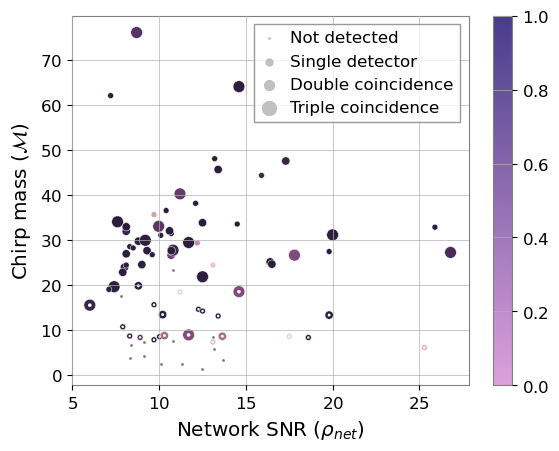

In [29]:
names, counts, probs, snrs, chirps, labels, inhull_ = list(), list(), list(), list(), list(), list(), list()
fig, ax = plt.subplots()
for i in range(len(compare)):
    tmp = compare.iloc[i]

    snr, chirp= merged_df.iloc[i]['SNR'], merged_df.iloc[i]['Chirp mass']
    
    if tmp['tripple_val'] is not None:
        if (tmp['double_val'] > tmp['tripple_val']) and (tmp['tripple_val'] < 0.67): # Double coincidence
            counts.append(50), probs.append(tmp['double_val'])
            snrs.append(snr), chirps.append(chirp), labels.append(tmp['double_lab'][-4:])
            names.append(merged_df.iloc[i]['Name'])
            inhull_.append(inHull[i])
        else: # Tripple coincidence
            counts.append(100), probs.append(tmp['tripple_val'])
            snrs.append(snr), chirps.append(chirp), labels.append('H1L1V1')
            names.append(merged_df.iloc[i]['Name'])
            inhull_.append(inHull[i])
    elif tmp['double_val'] is not None:

        if (tmp['single_val'] > tmp['double_val']) and (tmp['double_val'] < 0.75): # Single coincidence
            counts.append(25), probs.append(tmp['single_val'])
            snrs.append(snr), chirps.append(chirp), labels.append(tmp['single_lab'][-2:])
            names.append(merged_df.iloc[i]['Name'])
            inhull_.append(inHull[i])
            
        else: # Double coincidence
            counts.append(50), probs.append(tmp['double_val'])
            snrs.append(snr), chirps.append(chirp), labels.append(tmp['double_lab'][-4:])
            names.append(merged_df.iloc[i]['Name'])
            inhull_.append(inHull[i])

    elif tmp['single_val'] is not None: # Single coincidence
        counts.append(25), probs.append(tmp['single_val'])
        snrs.append(snr), chirps.append(chirp), labels.append(tmp['single_lab'][-2:])
        names.append(merged_df.iloc[i]['Name'])
        inhull_.append(inHull[i])
        
    else: # Not detected
        sns.scatterplot([snr], [chirp], s=5, color='grey')
    if i == 77: display(tmp)
cmap = LinearSegmentedColormap.from_list(name='test', colors=['plum', 'darkslateblue'])
print(len(snrs), len(inhull_))
ax = sns.scatterplot(snrs, chirps, hue=probs, size=np.asarray(counts)*2, cmap=cmap)

x, y,  s = list(), list(), list()
for i in range(len(inhull_)):
    if inhull_[i] == 'p':
        x.append(snrs[i])
        y.append(chirps[i])

        s.append(int(counts[i]))

plt.scatter(x, y,  s=np.asarray(s)/40, marker='o', color='white')
#cbar = ax.colorbar(label =r'Probability of Injection class ($\bar{P}_{inj}$)')
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])
ax.figure.colorbar(sm)

g1 = plt.scatter([],[], s=1, marker='o', color='silver')
g2 = plt.scatter([],[], s=25, marker='o', color='silver')
g3 = plt.scatter([],[], s=50, marker='o', color='silver')
g4 = plt.scatter([],[], s=100, marker='o', color='silver')

plt.legend((g1, g2, g3, g4),
       ('Not detected', 'Single detector', 'Double coincidence', 'Triple coincidence'),
       scatterpoints=1,
       ncol=1,)

plt.xlabel(r'Network SNR ($\rho_{net}$)'), plt.ylabel(r'Chirp mass $(\mathcal{M}$)')
plt.savefig('GWOSCprobinj.pdf',
                format="pdf", bbox_inches="tight", rasterized=True)

In [30]:
gw_events_new = pd.DataFrame({'Name':names,
                          'rho':snrs, 
                          'M':chirps,
                          'I':labels, 'P\_inj':probs, 'inHull':inhull_})
#gw_events_new['P\_inj'] = gw_events['P\_inj'].round(5)

In [31]:
merged_df.columns

Index(['Name', 'SNR', 'Chirp mass', 'Mass1', 'Mass2', 'Ifos_H1', 'SNR_H1',
       'Chirp mass_H1', 'Probability_H1', 'Ifos_L1', 'SNR_L1', 'Chirp mass_L1',
       'Probability_L1', 'Ifos_V1', 'SNR_V1', 'Chirp mass_V1',
       'Probability_V1', 'Ifos_H1L1', 'SNR_H1L1', 'Chirp mass_H1L1',
       'Probability_H1L1', 'Ifos_L1V1', 'SNR_L1V1', 'Chirp mass_L1V1',
       'Probability_L1V1', 'Ifos_H1V1', 'SNR_H1V1', 'Chirp mass_H1V1',
       'Probability_H1V1', 'Ifos_H1L1V1', 'SNR_H1L1V1', 'Chirp mass_H1L1V1',
       'Probability_H1L1V1'],
      dtype='object')

In [32]:
frac1 = 1/merged_df['Probability_H1']
frac2 = 1/merged_df['Probability_L1']
frac3 = 1/merged_df['Probability_L1']

H_h1, H_l1, H_v1 = merged_df['Probability_H1'], merged_df['Probability_L1'], merged_df['Probability_V1']
H_h1l1, H_l1v1, H_h1v1 = 2/(frac1+frac2), 2/(frac2+frac3), 2/(frac1+frac3)
H_h1l1v1 = 3/(frac1 + frac2+frac3)

In [33]:
merged_df.loc[merged_df['Name'] == 'GW191215_223052']

,Name,SNR,Chirp mass,Mass1,Mass2,Ifos_H1,SNR_H1,Chirp mass_H1,Probability_H1,Ifos_L1,SNR_L1,Chirp mass_L1,Probability_L1,Ifos_V1,SNR_V1,Chirp mass_V1,Probability_V1,Ifos_H1L1,SNR_H1L1,Chirp mass_H1L1,Probability_H1L1,Ifos_L1V1,SNR_L1V1,Chirp mass_L1V1,Probability_L1V1,Ifos_H1V1,SNR_H1V1,Chirp mass_H1V1,Probability_H1V1,Ifos_H1L1V1,SNR_H1L1V1,Chirp mass_H1L1V1,Probability_H1L1V1
59,GW191215_223052,11.20,18.40,24.90,18.10,NaN,nan,nan,nan,L1,11.20,18.40,0.02,NaN,nan,nan,nan,H1L1,11.20,18.40,0.01,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan


In [34]:
harmonic = pd.DataFrame({'Name': merged_df['Name'], 
              'H1':H_h1, 'L1':H_l1, 'V1':H_v1, 
              'H1L1':H_h1l1, 'L1V1':H_l1v1, 'H1V1':H_h1v1, 'H1L1V1':H_h1l1v1})

single_val = harmonic[['H1','L1', 'V1']].max(axis=1)
single_lab = harmonic[['H1','L1', 'V1']].idxmax(axis=1)
double_val = harmonic[['H1L1','L1V1', 'L1V1']].max(axis=1)
double_lab = harmonic[['H1L1','L1V1', 'L1V1']].idxmax(axis=1)
tripple_val = harmonic['H1L1V1']

compare_harmonic = pd.DataFrame({'Name': merged_df['Name'],
                                 'single_val':single_val,'single_lab':single_lab, 
                        'double_val':double_val, 'double_lab': double_lab, 
                        'tripple_val': tripple_val})
compare_harmonic = compare_harmonic.replace({np.nan: None})
compare_harmonic = compare_harmonic.round(1)

GW190412 1.0 1.0 L1V1
GW190424_180648 1.0 1.0 L1V1
GW190521_074359 1.0 1.0 L1V1
GW190602_175927 0.99973744 0.99973744 L1V1
GW190620_030421 1.0 1.0 L1V1
GW190630_185205 1.0 1.0 L1V1
GW190708_232457 0.9823166999999999 0.9823166999999998 L1V1
GW190910_112807 1.0 1.0 L1V1
GW190930_133541 0.9999974 0.9999974000000001 L1V1
GW191103_012549 0.8660952 0.8660952 L1V1
GW200112_155838 1.0 1.0 L1V1


Name           GW200209_085452
single_val                1.00
single_lab                  H1
double_val                0.31
double_lab                H1L1
tripple_val               0.25
Name: 77, dtype: object

GW200220_124850 1.0 1.0 L1V1


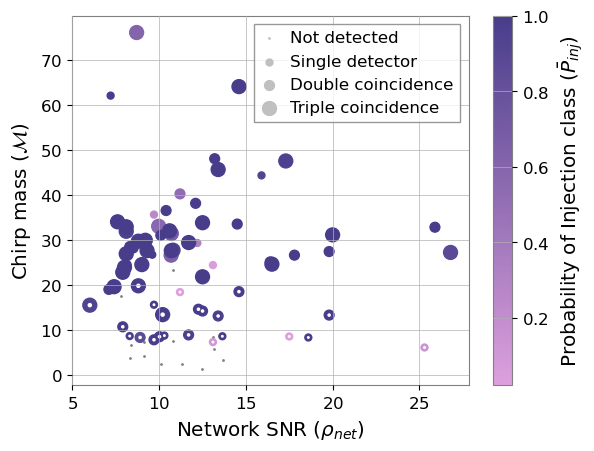

In [35]:
names, counts, probs, snrs, chirps, labels = list(), list(), list(), list(), list(), list()
plt.scatter(merged_df['SNR'], merged_df['Chirp mass'], s=1, color='grey')
k = 0
for i in range(len(compare_harmonic)):
    tmp = compare_harmonic.iloc[i]
    snr, chirp = merged_df.iloc[i]['SNR'], merged_df.iloc[i]['Chirp mass']
    if tmp['tripple_val'] is not None:
        if (tmp['double_val'] >= tmp['tripple_val']) and (tmp['tripple_val'] < 0.5): # Double coincidence
            if (tmp['double_val'] < 0.5):
                counts.append(25), probs.append(tmp['single_val'])
                snrs.append(snr), chirps.append(chirp), labels.append(tmp['single_lab'][-2:])
                names.append(merged_df.iloc[i]['Name'])
            else:
                counts.append(50), probs.append(tmp['double_val'])
                snrs.append(snr), chirps.append(chirp), labels.append(tmp['double_lab'][-4:])
                names.append(merged_df.iloc[i]['Name'])
        elif (tmp['tripple_val'] > 0.5): # Tripple coincidence
            counts.append(100), probs.append(tmp['tripple_val'])
            snrs.append(snr), chirps.append(chirp), labels.append('H1L1V1')
            names.append(merged_df.iloc[i]['Name'])
    elif tmp['double_val'] is not None:

        if (tmp['single_val'] >= tmp['double_val'] - 0.000001) and (tmp['double_val'] < 0.5): # Single coincidence
            
            counts.append(25), probs.append(tmp['single_val'])
            snrs.append(snr), chirps.append(chirp), labels.append(tmp['single_lab'][-2:])
            names.append(merged_df.iloc[i]['Name'])
            
        else: # Double coincidence
            print(merged_df.iloc[i]['Name'], tmp['single_val'], tmp['double_val'], tmp['double_lab'])
            counts.append(50), probs.append(tmp['double_val'])
            snrs.append(snr), chirps.append(chirp), labels.append(tmp['double_lab'][-4:])
            names.append(merged_df.iloc[i]['Name'])

    elif tmp['single_val'] is not None: # Single coincidence
        counts.append(25), probs.append(tmp['single_val'])
        snrs.append(snr), chirps.append(chirp), labels.append(tmp['single_lab'][-2:])
        names.append(merged_df.iloc[i]['Name'])
        
    else:
        k = k +1# Not detected
        pass
    if i == 77: display(tmp)

cmap = LinearSegmentedColormap.from_list(name='test', colors=['plum', 'darkslateblue'])
plt.scatter(snrs, chirps, c=probs, s=counts, cmap=cmap)
cbar = plt.colorbar(label =r'Probability of Injection class ($\bar{P}_{inj}$)')
x, y,  s = list(), list(), list()
for i in range(len(inhull_)):
    if inhull_[i] == 'p':
        x.append(snrs[i])
        y.append(chirps[i])

        s.append(int(counts[i]))

plt.scatter(x, y,  s=np.asarray(s)/20, marker='o', color='white')


g1 = plt.scatter([],[], s=1, marker='o', color='silver')
g2 = plt.scatter([],[], s=25, marker='o', color='silver')
g3 = plt.scatter([],[], s=50, marker='o', color='silver')
g4 = plt.scatter([],[], s=100, marker='o', color='silver')

plt.legend((g1, g2, g3, g4),
       ('Not detected', 'Single detector', 'Double coincidence', 'Triple coincidence'),
       scatterpoints=1,
       ncol=1,)

plt.xlabel(r'Network SNR ($\rho_{net}$)'), plt.ylabel(r'Chirp mass $(\mathcal{M}$)')
plt.savefig('GWOSCprobinj.pdf',
                format="pdf", bbox_inches="tight", rasterized=True)

In [38]:
gw_events_new = pd.DataFrame({'Name':names,
                          'rho':snrs, 
                          'M':chirps,
                          'I':labels, 'P\_inj':probs, 'inHull':inhull_})
gw_events_new = gw_events_new.replace('_','\_', regex=True)


In [39]:
# Group by 'Group' column
grouped = gw_events_new.groupby(by=['I'])

# Iterate over groups
for group_name, group_df in grouped:
    print(f"Group: {group_name}")
    
    #display(group_df.sort_values(by='$\bar{P}_{inj}$', ascending=False))
    # Convert DataFrame to LaTeX table
    table = group_df.sort_values(by='P\_inj', ascending=False)
    column1_formatter = lambda x: f"{x:.2f}"
    table["P\_inj"] = table["P\_inj"].apply(column1_formatter)
    
    column2_formatter = lambda x: f"{x:.1f}"
    table["rho"] = table["rho"].apply(column2_formatter)
    table["M"] = table["M"].apply(column2_formatter)
    table = table.replace('nan','-', regex=True)
    table = table.replace('H1','H', regex=True)
    table = table.replace('L1','L', regex=True)
    table = table.replace('V1','V', regex=True)
    latex_table = table.to_latex(index=False, escape=False,
                                 column_format='c'*table.shape[1],
                                 caption='This is a table caption', label='tab:det'+group_name)

    # Print or save the LaTeX table
    print(latex_table)

Group: H1
\begin{table}
\centering
\caption{This is a table caption}
\label{tab:detH1}
\begin{tabular}{cccccc}
\toprule
             Name &   rho &     M &  I & P\_inj & inHull \\
\midrule
 GW200220\_061928 &   7.2 &  62.0 &  H &   1.00 &      o \\
   200114\_020818 &  14.5 &     - &  H &   1.00 &      p \\
 GW200209\_085452 &   9.6 &  26.7 &  H &   1.00 &      o \\
 GW191126\_115259 &   8.3 &   8.7 &  H &   0.98 &      p \\
 GW190519\_153544 &  15.9 &  44.3 &  H &   0.92 &      o \\
 GW190503\_185404 &  12.2 &  29.3 &  H &   0.33 &      o \\
   200214\_224526 &  13.1 &     - &  H &   0.16 &      p \\
\bottomrule
\end{tabular}
\end{table}

Group: H1L1
\begin{table}
\centering
\caption{This is a table caption}
\label{tab:detH1L1}
\begin{tabular}{cccccc}
\toprule
             Name &   rho &     M &   I & P\_inj & inHull \\
\midrule
 GW190701\_203306 &  11.2 &  40.2 &  HL &   0.52 &      o \\
\bottomrule
\end{tabular}
\end{table}

Group: H1L1V1
\begin{table}
\centering
\caption{This is a 

In [252]:
matrix = np.empty((len(merged_df), 7))
probability = np.empty((len(merged_df), 7))
for i in range(len(merged_df)):
    tmp = merged_df.iloc[i]
    k = 0
    for j, v in enumerate(np.arange(4, len(merged_df.columns), 4)):
        if np.isnan(tmp[v]):
            matrix[i][j] = 0
            probability[i][j] = 0
        else: 
            matrix[i][j] = 1
            probability[i][j] = tmp[v+2]
c1, c2, c3 = np.sum(matrix[:, 0:3], axis=1), np.sum(matrix[:, 3:6], axis=1), np.sum(matrix[:, 6:7], axis=1)

probs, sizes, ifos = list(), list(), list()
for c in range(len(c1)):
    if c3[c] != 0: 
        sizes.append(100)
        probs.append(probability[c, 6:7][0])
    else:
        if c2[c] != 0: 
            sizes.append(50)
            probs.append(np.max(probability[c, 3:6]))
            print(np.argmax(probability[c, 3:6]))
        else:
            if c1[c] != 0:
                sizes.append(25)
                probs.append(np.max(probability[c, :3]))
            else: 
                sizes.append(1)
                probs.append(0)

IndexError: index 7 is out of bounds for axis 0 with size 7

In [251]:
merged_df

,Name,SNR,Chirp mass,Ifos_H1,SNR_H1,Chirp mass_H1,Probability_H1,Ifos_L1,SNR_L1,Chirp mass_L1,Probability_L1,Ifos_V1,SNR_V1,Chirp mass_V1,Probability_V1,Ifos_H1L1,SNR_H1L1,Chirp mass_H1L1,Probability_H1L1,Ifos_L1V1,SNR_L1V1,Chirp mass_L1V1,Probability_L1V1,Ifos_H1V1,SNR_H1V1,Chirp mass_H1V1,Probability_H1V1,Ifos_H1L1V1,SNR_H1L1V1,Chirp mass_H1L1V1,Probability_H1L1V1,Count,Prob
0,GW190403_051519,7.60,34.00,H1,7.60,34.00,1.00,L1,7.60,34.00,0.05,V1,7.60,34.00,1.00,H1L1,7.60,34.00,1.00,L1V1,7.60,34.00,0.52,H1V1,7.60,34.00,1.00,H1L1V1,7.60,34.00,1.00,100,1.00
1,GW190408_181802,14.60,18.50,H1,14.60,18.50,0.05,L1,14.60,18.50,1.00,V1,14.60,18.50,1.00,H1L1,14.60,18.50,0.53,L1V1,14.60,18.50,1.00,H1V1,14.60,18.50,0.53,H1L1V1,14.60,18.50,0.68,100,0.68
2,GW190412,19.80,13.30,NaN,nan,nan,nan,L1,19.80,13.30,1.00,V1,19.80,13.30,1.00,H1L1,19.80,13.30,0.50,L1V1,19.80,13.30,1.00,H1V1,19.80,13.30,0.50,H1L1V1,19.80,13.30,0.67,100,0.67
3,GW190413_052954,9.00,24.50,H1,9.00,24.50,0.96,L1,9.00,24.50,1.00,NaN,nan,nan,nan,H1L1,9.00,24.50,0.98,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,50,0.98
4,GW190413_134308,9.97,33.00,H1,9.97,33.00,1.00,L1,9.97,33.00,0.48,V1,9.97,33.00,1.00,H1L1,9.97,33.00,0.74,L1V1,9.97,33.00,0.74,H1V1,9.97,33.00,1.00,H1L1V1,9.97,33.00,0.83,100,0.83
5,GW190421_213856,10.70,31.40,H1,10.70,31.40,0.43,L1,10.70,31.40,1.00,NaN,nan,nan,nan,H1L1,10.70,31.40,0.71,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,50,0.71
6,GW190424_180648,10.09,31.00,NaN,nan,nan,nan,L1,10.09,31.00,1.00,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,25,1.00
7,GW190425,12.46,1.44,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,1,0.00
8,GW190426_152155,10.12,2.41,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,NaN,nan,nan,nan,1,0.00
9,GW190426_190642,8.70,76.00,H1,8.70,76.00,1.00,L1,8.70,76.00,0.51,V1,8.70,76.00,1.00,H1L1,8.70,76.00,0.75,L1V1,8.70,76.00,0.75,H1V1,8.70,76.00,1.00,H1L1V1,8.70,76.00,0.84,100,0.84


In [244]:
tmp.loc[16]['Probability_H1'], tmp.loc[16]['Probability_L1'], 
tmp.loc[16]['Probability_H1L1V1'], tmp.columns

(0.9986381933333334,
 Index(['Name', 'SNR', 'Chirp mass', 'Ifos_H1', 'SNR_H1', 'Chirp mass_H1',
        'Probability_H1', 'Ifos_L1', 'SNR_L1', 'Chirp mass_L1',
        'Probability_L1', 'Ifos_V1', 'SNR_V1', 'Chirp mass_V1',
        'Probability_V1', 'Ifos_H1L1', 'SNR_H1L1', 'Chirp mass_H1L1',
        'Probability_H1L1', 'Ifos_L1V1', 'SNR_L1V1', 'Chirp mass_L1V1',
        'Probability_L1V1', 'Ifos_H1V1', 'SNR_H1V1', 'Chirp mass_H1V1',
        'Probability_H1V1', 'Ifos_H1L1V1', 'SNR_H1L1V1', 'Chirp mass_H1L1V1',
        'Probability_H1L1V1', 'Count', 'Prob'],
       dtype='object'))

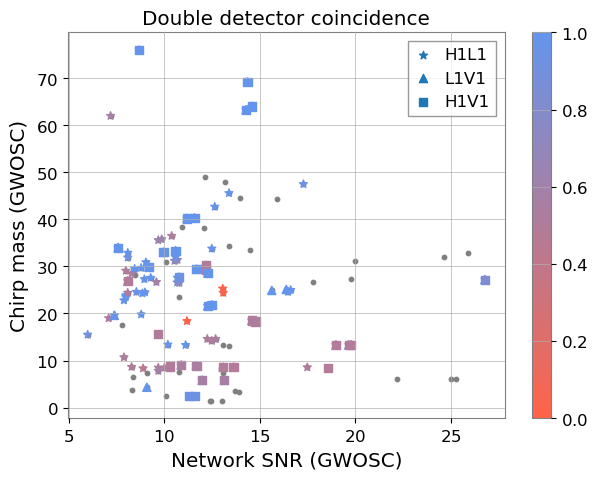

In [87]:

fig = plt.figure(dpi=100)
plt.scatter(events['network_matched_filter_snr'], events['chirp_mass_source'],
            s=10, c='grey')
for ifos, m in zip(['H1L1', 'L1V1', 'H1V1'], ['*', '^', 's']):
    cmap = LinearSegmentedColormap.from_list(
        name='test', 
        colors=['tomato', 'cornflowerblue'])
    ifo1, ifo2 = ifos[:2], ifos[2:]
    df = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_'+ifos+'.csv')

    names, net_snrs, chirp_mass, probs = list(), list(), list(), list()
    for t in range(len(events)):

        time = events.iloc[t]['GPS']

        tmp = df.loc[(df['Cluster time_'+ifo1] >= time - 1) & (df['Cluster time_'+ifo1] <= time + 1)]
        names.append(events.iloc[t]['commonName'])
        net_snrs.append(events.iloc[t]['network_matched_filter_snr'])
        chirp_mass.append(events.iloc[t]['chirp_mass_source'])
        if len(tmp) == 0 :
            probs.append(0)
        else:
            probs.append((tmp['Prob0_'+ifos[:2]].values[0] + tmp['Prob0_'+ifos[2:]].values[0])/2)
    gw_detection = pd.DataFrame({'Name': names, 'SNR':net_snrs,
                             'Chirp mass':chirp_mass, 'Probability':probs})
    gw_detection_ = gw_detection.loc[(gw_detection['Probability'] > 0.01)]
  
    plt.scatter(gw_detection_['SNR'], gw_detection_['Chirp mass'],
                c=gw_detection_['Probability'], vmin=0, vmax=1, s=35, marker=m,
                cmap=cmap, label=ifos)
plt.colorbar()
plt.xlabel('Network SNR (GWOSC)')
plt.ylabel('Chirp mass (GWOSC)')
plt.tight_layout()
plt.title('Double detector coincidence')
plt.legend()

In [14]:
events_marginal = events.loc[events['catalog.shortName'] =='O3_IMBH_marginal']
events_marginal

,id,commonName,version,catalog.shortName,GPS,reference,jsonurl,mass_1_source,mass_1_source_lower,mass_1_source_upper,...,redshift_upper,far,far_lower,far_upper,p_astro,p_astro_lower,p_astro_upper,final_mass_source,final_mass_source_lower,final_mass_source_upper
14,190924_232654-v1,190924_232654,1,O3_IMBH_marginal,1253402833.00,/O3_IMBH_marginal/,https://www.gw-openscience.org/eventapi/json/O3_IMBH_marginal/190924_232654/v1,nan,nan,nan,...,nan,0.40,nan,nan,nan,nan,nan,nan,nan,nan
16,191223_014159-v1,191223_014159,1,O3_IMBH_marginal,1261100537.60,/O3_IMBH_marginal/,https://www.gw-openscience.org/eventapi/json/O3_IMBH_marginal/191223_014159/v1,nan,nan,nan,...,nan,0.46,nan,nan,nan,nan,nan,nan,nan,nan
17,191225_215715-v1,191225_215715,1,O3_IMBH_marginal,1261346253.90,/O3_IMBH_marginal/,https://www.gw-openscience.org/eventapi/json/O3_IMBH_marginal/191225_215715/v1,nan,nan,nan,...,nan,0.47,nan,nan,nan,nan,nan,nan,nan,nan
18,200114_020818-v1,200114_020818,1,O3_IMBH_marginal,1263002916.20,/O3_IMBH_marginal/,https://www.gw-openscience.org/eventapi/json/O3_IMBH_marginal/200114_020818/v1,nan,nan,nan,...,nan,0.06,nan,nan,nan,nan,nan,nan,nan,nan
21,200214_224526-v1,200214_224526,1,O3_IMBH_marginal,1265755544.50,/O3_IMBH_marginal/,https://www.gw-openscience.org/eventapi/json/O3_IMBH_marginal/200214_224526/v1,nan,nan,nan,...,nan,0.13,nan,nan,nan,nan,nan,nan,nan,nan


,Name,SNR,Num templates,Probability,GPS,Cluster GPS
4,200214_224526,13.10,2,0.81,1265755544.50,1265755543.89


,Name,SNR,Num templates,Probability,GPS,Cluster GPS
0,190924_232654,13.27,54,0.45,1253402833.00,1253402832.93
4,200214_224526,13.10,6,0.03,1265755544.50,1265755544.72


,Name,SNR,Num templates,Probability,GPS,Cluster GPS
0,190924_232654,13.27,36,1.00,1253402833.00,1253402832.97
4,200214_224526,13.10,6,1.00,1265755544.50,1265755544.80


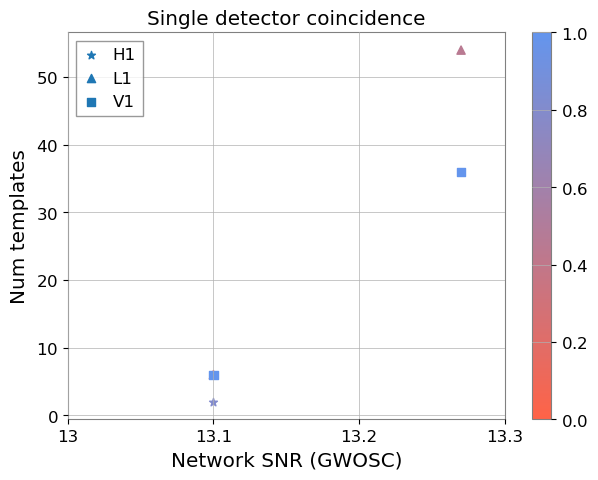

In [48]:

fig = plt.figure(dpi=100)
plt.scatter(events_marginal['network_matched_filter_snr'],
            events_marginal['chirp_mass_source'],
            s=10, c='grey')

for ifos, m in zip(['H1', 'L1', 'V1'], ['*', '^', 's']):
    cmap = LinearSegmentedColormap.from_list(
        name='test', 
        colors=['tomato', 'cornflowerblue'])
    ifo1 = ifos
    df = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_'+ifos+'.csv')

    names, net_snrs, num_templates, probs, gps, gps_ = list(), list(), list(), list(), list(), list()
    for t in range(len(events_marginal)):

        time = events_marginal.iloc[t]['GPS']

        tmp = df.loc[(df['Cluster time'] >= time - 1) & (df['Cluster time'] <= time + 1)]
        names.append(events_marginal.iloc[t]['commonName'])
        net_snrs.append(events_marginal.iloc[t]['network_matched_filter_snr'])
        gps.append(events_marginal.iloc[t]['GPS'])

        if len(tmp) == 0 :
            probs.append(0)
            num_templates.append(0)
            gps_.append(0)
        else:
            gps_.append(tmp['Cluster time'].values[0])

            num_templates.append(tmp['Num triggers'].values[0])
            probs.append((tmp['Prob0'].values[0] + tmp['Prob0'].values[0])/2)
    gw_detection = pd.DataFrame({'Name': names, 'SNR':net_snrs,
                             'Num templates':num_templates, 'Probability':probs,
                                 'GPS':gps, 'Cluster GPS':gps_})
    gw_detection_ = gw_detection.loc[(gw_detection['Probability'] > 0.01)]
    
    plt.scatter(gw_detection_['SNR'], gw_detection_['Num templates'],
                c=gw_detection_['Probability'],
                vmin=0, vmax=1, s=35, marker=m, cmap=cmap,label=ifos)
    display(gw_detection_)
plt.colorbar()
plt.xlabel('Network SNR (GWOSC)')
plt.ylabel('Num templates')
plt.xticks([13, 13.1, 13.2, 13.3], [13, 13.1, 13.2, 13.3])
plt.tight_layout()
plt.title('Single detector coincidence')
plt.legend()

### Glitches

In [90]:
!ls ../output_new/tw0.05/

95.42Acc_L1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_3505epochs_10batches
95.42Acc_L1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_3505epochs_10batchesAcc_L1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_3505epochs_10batchessummary.npy
95.42Acc_L1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_3505epochs_10batches.png
95.42Acc_L1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_3505epochs_10batches.pth
98.72Acc_H1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_2771epochs_10batches
98.72Acc_H1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_2771epochs_10batchesAcc_H1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_2771epochs_10batchessummary.npy
98.72Acc_H1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_2771epochs_10batches.png
98.72Acc_H1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_2771epochs_10batches.pth
99.05Acc_V1_Th

#### Double coincidence

705426
183272
10212
8530
8431
8350
279


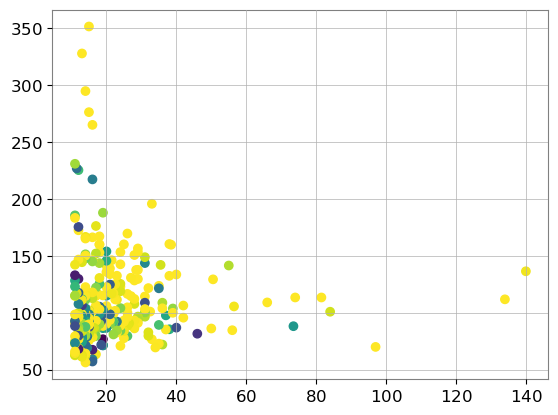

In [6]:
ifos = 'H1L1'
ifo1, ifo2 = ifos[:2], ifos[2:]

df = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_'+ifos+'.csv')
df = df.loc[:, ~df.columns.str.match('Unnamed')]
print(len(df))
df = df.loc[(df['Prob0_'+ifo1] > 0.9) & (df['Prob0_'+ifo2] > 0.9)]
print(len(df))
df = df.loc[(df['Num triggers_'+ifo1] > 10) & (df['Num triggers_'+ifo2] > 10)]
print(len(df))
df = df.loc[(df['Mass_1_'+ifo1] - 3 < df['Mass_1_'+ifo2]) & (df['Mass_1_'+ifo1] + 3 > df['Mass_1_'+ifo2])]
print(len(df))
df = df.loc[(df['Mass_2_'+ifo1] - 3 < df['Mass_2_'+ifo2]) & (df['Mass_2_'+ifo1] + 3 > df['Mass_2_'+ifo2])]
print(len(df))
df = df.loc[(df['SNR_'+ifo1] - 3 < df['SNR_'+ifo2]) & (df['SNR_'+ifo1] + 3 > df['SNR_'+ifo2])]
print(len(df))
df = df.loc[(df['SNR_'+ifo1] > 5) & (df['SNR_'+ifo2] > 5)]
print(len(df))
df = df.sort_values(by=['Num triggers_'+ifo1, 'Num triggers_'+ifo2], ascending=False)

chirpmass = (df['Mass_1_'+ifo1]*df['Mass_2_'+ifo1]**(3/5)/(df['Mass_1_'+ifo1]+df['Mass_2_'+ifo1])**(1/5))
plt.scatter((df['Num triggers_'+ifo1]+df['Num triggers_'+ifo2])/2, chirpmass, c=(df['Prob0_'+ifo1]+df['Prob0_'+ifo2])/2)

In [7]:
!ls /data/gravwav/lopezm/Projects/GlitchBank/data-visualization-and-optimisation/Results/

test_H1L1.csv


In [23]:
df.to_pickle('/data/gravwav/lopezm/Projects/GlitchBank/data-visualization-and-optimisation/Results/test_H1L1.csv')

In [22]:
events = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/allevents.csv')
events = events.loc[events['GPS']>1238166018].sort_values(by='GPS')
pars = list()
for t in range(100):
    t_star = df.iloc[t]['Cluster time_'+ifo1]
    try:
        gwosc = detectedGWOSC(events, t_star, df, t)
    except KeyError as e:
        print(e)
        gwosc = False
    if gwosc:
        print('GWOSC detected')
        print(t, t_star,
              df.iloc[t]['Prob0_'+ifo1], df.iloc[t]['Prob0_'+ifo2],
              df.iloc[t]['Num triggers_'+ifo1], df.iloc[t]['Num triggers_'+ifo2], 
              df.iloc[t]['SNR_'+ifo1], df.iloc[t]['SNR_'+ifo2],
              df.iloc[t]['Mass_1_'+ifo1], df.iloc[t]['Mass_1_'+ifo2], df.iloc[t]['Mass_2_'+ifo1], df.iloc[t]['Mass_2_'+ifo2])

    else:
        pass
    """
        print(' New! ')
        
        pars.append([t_star,
              df.iloc[t]['Prob0_'+ifo1], df.iloc[t]['Prob0_'+ifo2],
              df.iloc[t]['Num triggers_'+ifo1], df.iloc[t]['Num triggers_'+ifo2], 
              df.iloc[t]['SNR_'+ifo1], df.iloc[t]['SNR_'+ifo2],
              df.iloc[t]['Mass_1_'+ifo1], df.iloc[t]['Mass_1_'+ifo2], df.iloc[t]['Mass_2_'+ifo1], df.iloc[t]['Mass_2_'+ifo2]])


        fig, ax = plt.subplots(1, 2, dpi=120)
        for i, ifo in enumerate([ifo1, ifo2]):
            strain = TimeSeries.get(channel=ifo + 'DCS-CALIB_STRAIN_CLEAN_SUB60HZ_C01', t_star - 1, t_star + 1)
            # Perform q-transform
            q_scan = strain.q_transform(qrange=[4, 64], frange=[10, 2048],
                                     tres=0.002, fres=0.5, whiten=True)

            # Plot spectrogram
            ax[i].imshow(q_scan, cmap='viridis', vmin=0, vmax=25.5,label=ifo)
            ax[i].axvline(df.iloc[t]['Cluster time_'+ifo], c='crimson', alpha=0.5)
            ax[i].set_yscale('log', base=2)
            ax[i].set_xscale('linear')
            ax[0].set_ylabel('Frequency (Hz)', fontsize=14)
            ax[1].yaxis.set_ticks_position('none')
            #ax[i].set_xlabel('Time (s)', labelpad=0.1, fontsize=14)
            ax[i].yaxis.set_major_formatter(ScalarFormatter())
            ax[i].tick_params(axis='both', which='major', labelsize=14)
        plt.show()
    print(' ')
    """

0 GW detected:  GW190408_181802 GWTC-2 0.9976834 1.0
0 GW detected:  GW190408_181802 GWTC-2.1-confident 0.9976834 1.0
GWOSC detected
0 1246487219.3369794 0.9976834 1.0 151.0 129.0 7.898651832167954 7.666927219640066 77.74844982447337 77.91930489814554 11.39688584189232 10.600669911942038
1 GW detected:  GW190720_000836 GWTC-2 0.9999622 0.99999845
GWOSC detected
1 1261020955.123952 0.9999622 0.99999845 144.0 124.0 7.824814670397881 7.2073806410989425 65.1230866391966 67.88403997977863 10.393619287012443 10.145903798844165
3 GW detected:  GW190512_180714 GWTC-2.1-confident 0.99991155 1.0
3 GW detected:  GW190513_205428 GWTC-2 0.99991155 1.0
GWOSC detected
3 1251009263.7586608 0.99991155 1.0 78.0 85.0 9.917180270959001 10.388879254117569 56.51263523289491 59.03933639385768 13.126431578961403 14.065809419566055
8 GW detected:  GW190706_222641 GWTC-2.1-confident 0.98793113 1.0
GWOSC detected
8 1258866165.5492086 0.98793113 1.0 63.0 47.0 6.1297173819875095 5.842774960483463 69.88162377828094

#### Tripple coincidence

393351
110659
4600
4182
4135
4134
7


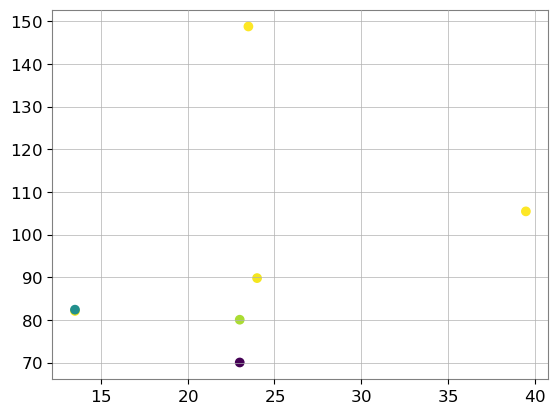

In [73]:
ifos = 'H1L1V1'
ifo1, ifo2, ifo3 = ifos[:2], ifos[2:4], ifos[4:]

df = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_'+ifos+'.csv')
df = df.loc[:, ~df.columns.str.match('Unnamed')]
print(len(df))
df = df.loc[(df['Prob0_'+ifo1] > 0.9) & (df['Prob0_'+ifo2] > 0.9) & (df['Prob0_'+ifo3] > 0.9) ]
print(len(df))
df = df.loc[(df['Num triggers_'+ifo1] > 10) & (df['Num triggers_'+ifo2] > 10) & (df['Num triggers_'+ifo3] > 10)]
print(len(df))
df = df.loc[(df['Mass_1_'+ifo1] - 3 < df['Mass_1_'+ifo2]) & (df['Mass_1_'+ifo1] + 3 > df['Mass_1_'+ifo2])]
df = df.loc[(df['Mass_1_'+ifo1] - 3 < df['Mass_1_'+ifo3]) & (df['Mass_1_'+ifo1] + 3 > df['Mass_1_'+ifo3])]
print(len(df))
df = df.loc[(df['Mass_2_'+ifo1] - 3 < df['Mass_2_'+ifo2]) & (df['Mass_2_'+ifo1] + 3 > df['Mass_2_'+ifo2])]
df = df.loc[(df['Mass_2_'+ifo1] - 3 < df['Mass_2_'+ifo3]) & (df['Mass_2_'+ifo1] + 3 > df['Mass_2_'+ifo3])]
print(len(df))
df = df.loc[(df['SNR_'+ifo1] - 3 < df['SNR_'+ifo2]) & (df['SNR_'+ifo1] + 3 > df['SNR_'+ifo2])]
df = df.loc[(df['SNR_'+ifo1] - 3 < df['SNR_'+ifo3]) & (df['SNR_'+ifo1] + 3 > df['SNR_'+ifo3])]
print(len(df))
df = df.loc[(df['SNR_'+ifo1] > 4.5) & (df['SNR_'+ifo2] > 4.5) & (df['SNR_'+ifo3] > 4.5)]
print(len(df))
df = df.sort_values(by=['Num triggers_'+ifo1, 'Num triggers_'+ifo2, 'Num triggers_'+ifo3], ascending=False)

chirpmass = (df['Mass_1_'+ifo1]*df['Mass_2_'+ifo1]**(3/5)/(df['Mass_1_'+ifo1]+df['Mass_2_'+ifo1])**(1/5))
plt.scatter((df['Num triggers_'+ifo1]+df['Num triggers_'+ifo2])/2, chirpmass, c=(df['Prob0_'+ifo1]+df['Prob0_'+ifo2])/2)

0 1251420746.4799552 0.99999774 1.0 0.9999558 31.0 48.0 48.0 5.357528700912527 4.8099668915243585 4.970557842183752 58.46441749550066 60.27364277101874 60.009887163758364 10.984288106544225 9.156117335134388 9.163912025191081
 New! 


/data/gravwav/lopezm/cmb_env/miniforge3/envs/ml_course/lib/python3.7/site-packages/gwpy/signal/qtransform.py:126: UserWarning: upper frequency of 2048.00 is too high for the given Q range, resetting to 1291.05
  % (self.frange[1], maxf))


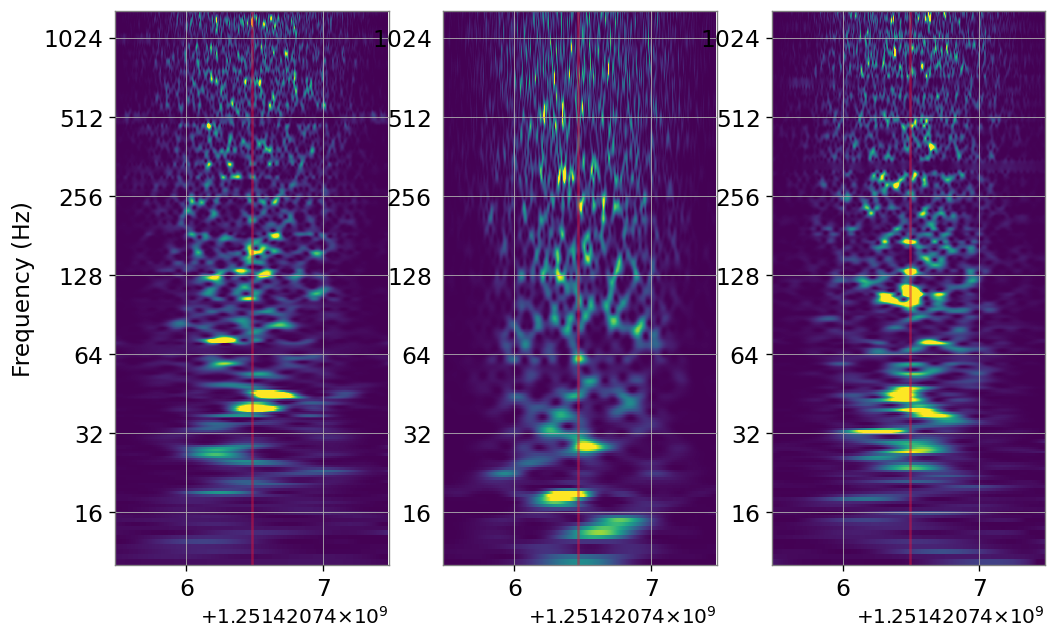

 
1 1262069067.4047625 0.99919647 0.9991285 0.955657 27.0 21.0 27.0 5.14840123489948 4.52510302924407 4.899450060428962 55.50854573418553 56.52889308992477 54.1894437449486 8.938921110467689 9.884086285485118 8.5848127866372
 New! 


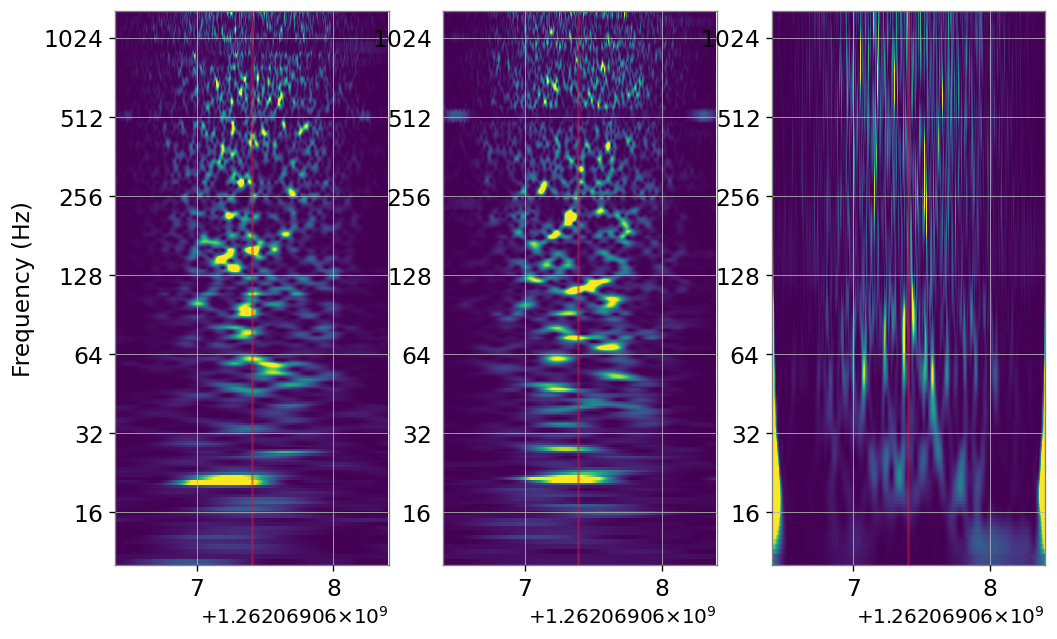

 
2 1251088086.9515483 0.98790956 0.999818 0.98840135 24.0 22.0 20.0 4.568764593846053 5.095759219228058 5.314339692020591 47.04113945031988 46.40866075940857 48.67450725823719 9.297462984144527 9.554329193898415 6.34918512164873
 New! 


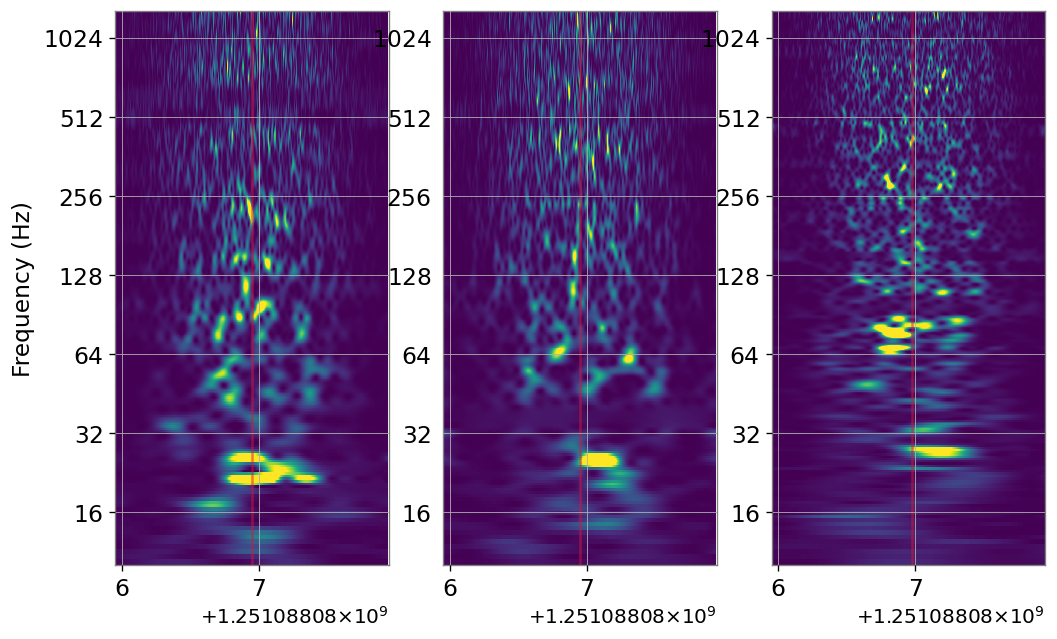

 
3 1241269460.0701554 1.0 1.0 1.0 23.0 24.0 23.0 4.794986283155554 4.815973723080051 4.905160965190658 70.89989934387062 69.43410175244722 70.79390362469496 15.187567243179982 15.039965179897752 14.731297213772953
 New! 


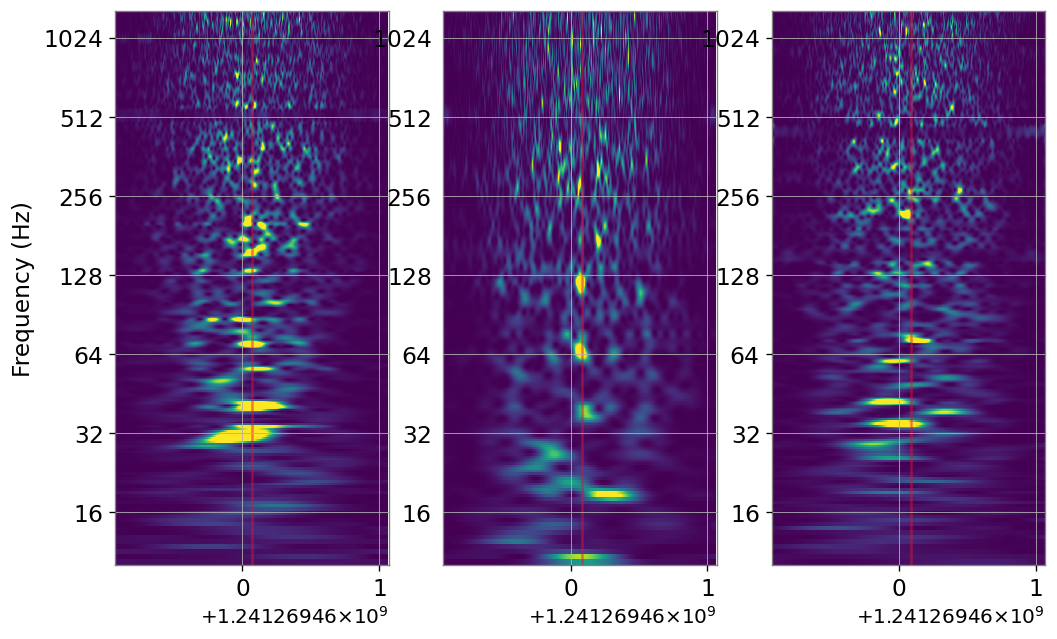

 
4 1242259819.0494125 0.9024719 1.0 0.9998945 23.0 23.0 23.0 4.59345193188201 4.7029177633015085 4.8133471519593405 44.59528184074832 44.728382298877904 44.55901481464756 7.944612264850386 7.7012786525934995 7.9783912752290425
 New! 


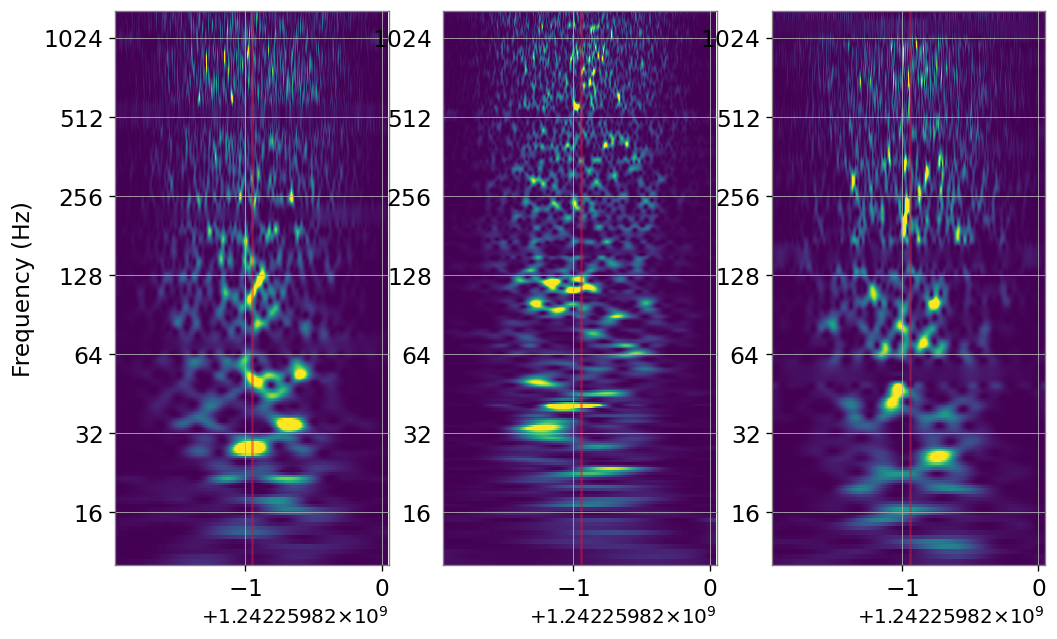

 
5 1262003708.0461512 0.9987078 0.999283 0.9433677 14.0 13.0 14.0 4.540654885878929 4.515794235988385 4.816240903561863 50.66600059241747 49.8096207073625 50.80562842525285 8.722898474494505 8.693487239657879 8.725493665849992
 New! 


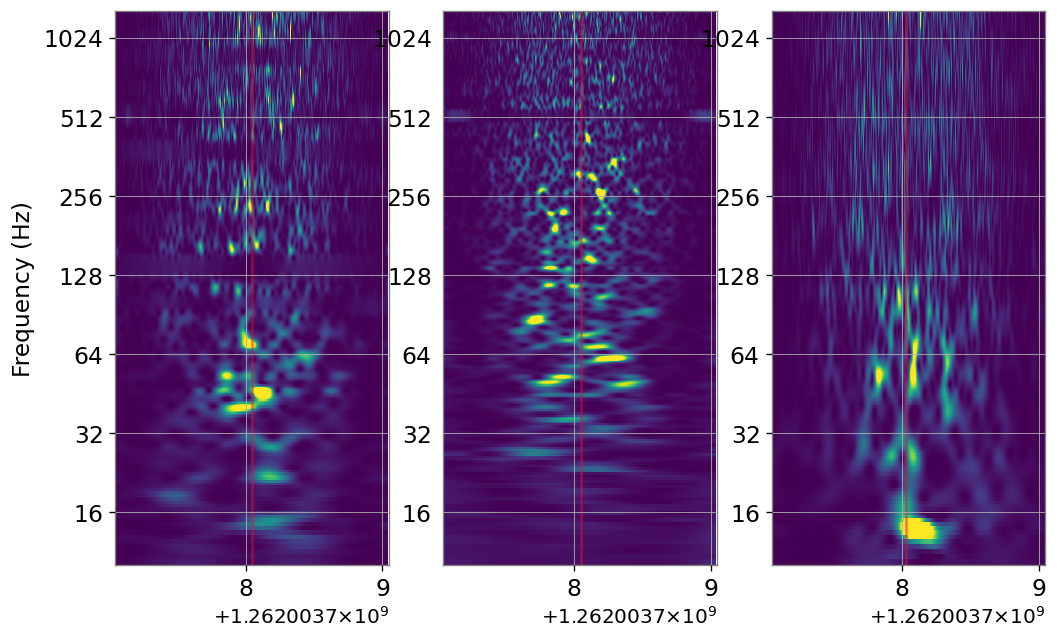

 
6 1250020124.5047512 0.9509312 0.9997708 0.9869153 13.0 14.0 14.0 4.552589839325415 4.691244052192 4.619193323746697 50.278349998857 50.65192853215842 51.12888909644249 8.876646672568803 8.625301515101013 7.861853517943801
 New! 


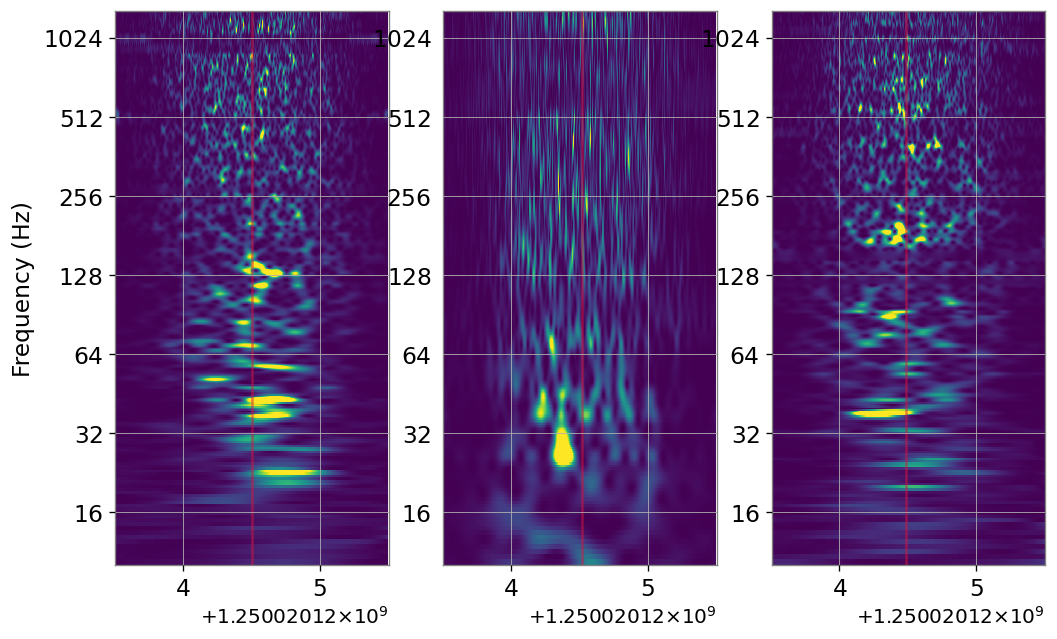

In [77]:
events = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/allevents.csv')
events = events.loc[events['GPS']>1238166018].sort_values(by='GPS')
pars = list()
for t in range(len(df)):
    t_star = df.iloc[t]['Cluster time_'+ifo1]
    print(t, t_star,
              df.iloc[t]['Prob0_'+ifo1], df.iloc[t]['Prob0_'+ifo2], df.iloc[t]['Prob0_'+ifo3],
              df.iloc[t]['Num triggers_'+ifo1], df.iloc[t]['Num triggers_'+ifo2], df.iloc[t]['Num triggers_'+ifo3],
              df.iloc[t]['SNR_'+ifo1], df.iloc[t]['SNR_'+ifo2], df.iloc[t]['SNR_'+ifo3],
              df.iloc[t]['Mass_1_'+ifo1], df.iloc[t]['Mass_1_'+ifo2], df.iloc[t]['Mass_1_'+ifo3],
              df.iloc[t]['Mass_2_'+ifo1], df.iloc[t]['Mass_2_'+ifo2], df.iloc[t]['Mass_2_'+ifo3])
    try:
        gwosc = detectedGWOSC(events, t_star)
    except KeyError as e:
        print(e)
        gwosc = False
    if gwosc:
        print('GWOSC detected')
    else:
        print(' New! ')
        
        pars.append([t_star,
              df.iloc[t]['Prob0_'+ifo1], df.iloc[t]['Prob0_'+ifo2], df.iloc[t]['Prob0_'+ifo3],
              df.iloc[t]['Num triggers_'+ifo1], df.iloc[t]['Num triggers_'+ifo2], df.iloc[t]['Num triggers_'+ifo3],
              df.iloc[t]['SNR_'+ifo1], df.iloc[t]['SNR_'+ifo2], df.iloc[t]['SNR_'+ifo3],
              df.iloc[t]['Mass_1_'+ifo1], df.iloc[t]['Mass_1_'+ifo2], df.iloc[t]['Mass_1_'+ifo3],
              df.iloc[t]['Mass_2_'+ifo1], df.iloc[t]['Mass_2_'+ifo2], df.iloc[t]['Mass_2_'+ifo3]])


        fig, ax = plt.subplots(1, len([ifo1, ifo2, ifo3]), figsize=(10, 6), dpi=120)
        for i, ifo in enumerate([ifo1, ifo2, ifo3]):
            strain = TimeSeries.fetch_open_data(ifo, t_star - 1, t_star + 1)
            # Perform q-transform
            q_scan = strain.q_transform(qrange=[4, 64], frange=[10, 2048],
                                     tres=0.002, fres=0.5, whiten=True)

            # Plot spectrogram
            ax[i].imshow(q_scan, cmap='viridis', vmin=0, vmax=25.5,label=ifo)
            ax[i].axvline(df.iloc[t]['Cluster time_'+ifo], c='crimson', alpha=0.5)
            ax[i].set_yscale('log', base=2)
            ax[i].set_xscale('linear')
            ax[0].set_ylabel('Frequency (Hz)', fontsize=14)
            ax[1].yaxis.set_ticks_position('none')
            #ax[i].set_xlabel('Time (s)', labelpad=0.1, fontsize=14)
            ax[i].yaxis.set_major_formatter(ScalarFormatter())
            ax[i].tick_params(axis='both', which='major', labelsize=14)
        plt.show()
    print(' ')

### Misc

In [3]:
def amazingStat2ifo(tmp_h1, tmp_l1):
    
    ph1 = tmp_h1['Prob0']
    pl1 = tmp_l1['Prob0'].values[0]
    snr_h1 = tmp_h1['SNR']
    snr_l1 = tmp_l1['SNR'].values[0]
    dt = np.abs(th1-tl1)
    dm1 = np.abs(tmp_h1['Mass_1'] - tmp_l1['Mass_1'].values[0])
    dm2 = np.abs(tmp_h1['Mass_2'] - tmp_l1['Mass_2'].values[0])
    sigma_m1 = 1
    sigma_m2 = 1
    sigma_snr = 2
    epsilon = 10**(-12)
    #As2ifo = np.log(ph1*pl1*np.exp((snr_h1 - snr_l1))*np.exp(np.abs(dt))*np.exp(- (dm1/sigma_m1) - (dm2/sigma_m2)))
    As2ifo = ph1*pl1*np.log(np.exp(np.abs(dt))*100 -dm1-dm2 + np.exp(snr_l1)+ np.exp(snr_h1))
    print(np.round(As2ifo, 3), ph1*pl1, np.log(np.exp(np.abs(dt))*1000+ np.exp(-dm1-dm2-epsilon) + np.exp((snr_h1+snr_l1)/sigma_snr)))
    
    #if np.abs(th1 - 1242442967.4) < 0.1:
    #    print('GW', As2ifo, ph1*pl1, np.log(np.exp(np.abs(dt))*1000+ np.exp(-dm1-dm2-epsilon) + np.exp((snr_h1+snr_l1)/sigma_snr)))
    #else:
    #    print(As2ifo, ph1*pl1, np.log(np.exp(np.abs(dt))*1000+ np.exp(-dm1-dm2-epsilon) + np.exp((snr_h1+snr_l1)/sigma_snr)))
    return th1, tl1, As2ifo

In [4]:
Th1, Tl1, As = list(), list(), list()
for i in range(len(pH1_)):
    tmp_h1 = pH1_.iloc[i]
    th1 = tmp_h1['Cluster time']
    tmp_l1 = pL1_[(pL1_['Cluster time'] > th1 -0.03) & (pL1_['Cluster time'] < th1 +0.03)]
    
    if len(tmp_l1) != 0:
        tl1 = tmp_l1['Cluster time'].values[0]
        #if (np.asarray(tmp_h1['Prob0']) > 0.9) and (np.asarray(tmp_l1['Prob0'].values[0]) > 0.9):

        ph1 = tmp_h1['Prob0']
        pl1 = tmp_l1['Prob0'].values[0]
        snr_h1 = tmp_h1['SNR']
        snr_l1 = tmp_l1['SNR'].values[0]
        dt = np.abs(th1-tl1)
        dm1 = np.abs(tmp_h1['Mass_1'] - tmp_l1['Mass_1'].values[0])
        dm2 = np.abs(tmp_h1['Mass_2'] - tmp_l1['Mass_2'].values[0])
        sigma_m1 = 2
        sigma_m2 = 2

        th1, tl1, stat = amazingStat2ifo(tmp_h1, tmp_l1)
        #if stat < -50:
        #print(th1 - tl1, stat)
        #q_scan = QScanht(th1-2, th1+2, 'H1')
        #plot(q_scan, th1-2, th1, th1+2)

        #q_scan = QScanht(tl1-2, tl1+2, 'L1')
        #plot(q_scan, tl1-2,tl1, tl1+2)
#print(th1 - tl1)

NameError: name 'pH1_' is not defined

In [177]:
display(pH1.loc[i].values)
print(pH1.columns.values)
pd.DataFrame(pH1.loc[i].values.reshape(1, -1), columns=pH1.columns)

array([ 5.12206320e+00,  9.55382530e-01,  3.94408340e+01,
        1.12026970e+01, -2.82003310e-01, -3.86371310e-01,
        9.51180300e-04,  6.55757500e-02,  3.34000000e-43,
        5.04718660e-10,  0.00000000e+00,  9.33473050e-01,
        2.93718530e-35,  5.04000000e+03,  1.23820792e+09])

['SNR' 'Chisq' 'Mass_1' 'Mass_2' 'Spin1z' 'Spin2z' 'Prob0'
 'Prob1' 'Prob2' 'Prob3' 'Prob4' 'Prob5' 'Prob6' 'Cluster ID'
 'Cluster time']


,SNR,Chisq,Mass_1,Mass_2,Spin1z,Spin2z,Prob0,Prob1,Prob2,Prob3,Prob4,Prob5,Prob6,Cluster ID,Cluster time
0,5.122063,0.955383,39.440834,11.202697,-0.282003,-0.386371,0.000951,0.065576,3.340000e-43,5.047187e-10,0.0,0.933473,2.937185e-35,5040.0,1.238208e+09


In [ ]:
tmp = pd.concat([tmp_h1, tmp_l1], axis=1)
tmp_h1.join(tmp_l1, lsuffix="_H1", rsuffix=("_L1"))


In [179]:
Th1, Tl1, As = list(), list(), list()
columns = pH1.columns
all_rows = list()
for i in range(len(pH1_)):
    tmp_h1 = pH1_.iloc[[i]].reset_index()
    th1 = tmp_h1['Cluster time'].values[0]
    tmp_l1 = pL1_[(pL1_['Cluster time'] > th1 -0.03) & (pL1_['Cluster time'] < th1 +0.03)].reset_index()
    
    if len(tmp_l1) != 0:
        tmp = tmp_h1.join(tmp_l1, lsuffix="_H1", rsuffix=("_L1"))
        all_rows.append(tmp.values[0])

In [2]:
merged = pd.DataFrame(all_rows, columns=tmp.columns)
gw190521 = merged[(merged['Cluster time_H1'] > 1242442967.4 -1) & (merged['Cluster time_H1'] < 1242442967.4 +1)]

NameError: name 'all_rows' is not defined

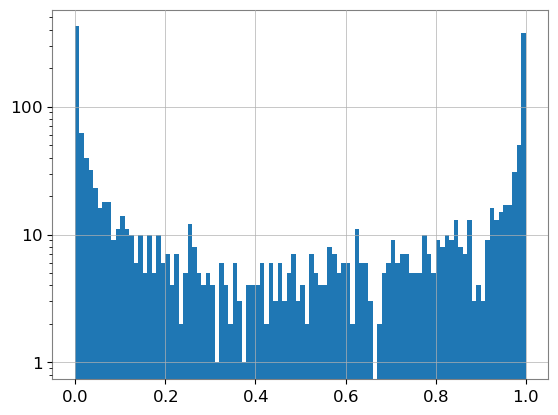

In [185]:
plt.hist(merged['Prob0_H1'], bins=100)
plt.yscale('log')

(array([ 24., 111., 216., 233., 257., 269., 246., 212.,  87.,
         16.]),
 array([-0.02910447, -0.02321193, -0.01731939, -0.01142685,
        -0.00553432,  0.00035822,  0.00625076,  0.0121433 ,
         0.01803584,  0.02392838,  0.02982092]),
 <BarContainer object of 10 artists>)

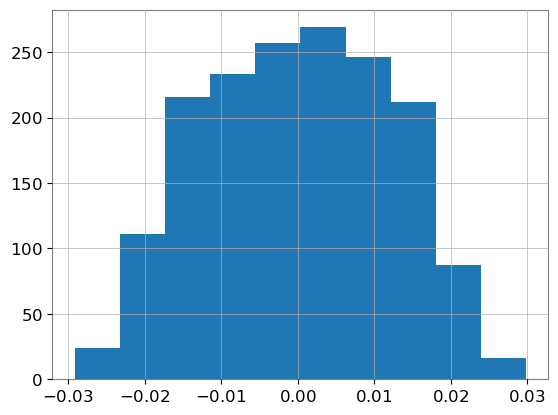

In [181]:
plt.hist(merged['Cluster time_H1']-merged['Cluster time_L1'])

In [186]:

ds1 = np.abs(merged['Spin1z_H1']-merged['Spin1z_L1'])
ds2 = np.abs(merged['Spin2z_H1']-merged['Spin2z_L1'])
dm1 = np.abs(merged['Mass_1_H1']-merged['Mass_1_L1'])
dm2 = np.abs(merged['Mass_2_H1']-merged['Mass_2_L1'])
dt = np.abs(merged['Cluster time_H1']-merged['Cluster time_L1'])
ph1 = merged['Prob0_H1']
pl1 = merged['Prob0_L1']
netSNR = np.sqrt(merged['SNR_H1']**2 +merged['SNR_L1']**2)
netChisq = np.sqrt(merged['Chisq_H1']**2+merged['Chisq_L1']**2)

ds1gw = np.abs(gw190521['Spin1z_H1']-gw190521['Spin1z_L1'])
ds2gw = np.abs(gw190521['Spin2z_H1']-gw190521['Spin2z_L1'])
dm1gw = np.abs(gw190521['Mass_1_H1']-gw190521['Mass_1_L1'])
dm2gw = np.abs(gw190521['Mass_2_H1']-gw190521['Mass_2_L1'])
dtgw = np.abs(gw190521['Cluster time_H1']-gw190521['Cluster time_L1'])
ph1gw = gw190521['Prob0_H1']
pl1gw = gw190521['Prob0_L1']
netSNRgw = np.sqrt(gw190521['SNR_H1']**2 + gw190521['SNR_L1']**2)
netChisqgw = np.sqrt(gw190521['Chisq_H1']**2+gw190521['Chisq_L1']**2)


merged.columns

Index(['index_H1', 'SNR_H1', 'Chisq_H1', 'Mass_1_H1', 'Mass_2_H1', 'Spin1z_H1',
       'Spin2z_H1', 'Prob0_H1', 'Prob1_H1', 'Prob2_H1', 'Prob3_H1', 'Prob4_H1',
       'Prob5_H1', 'Prob6_H1', 'Cluster ID_H1', 'Cluster time_H1', 'index_L1',
       'SNR_L1', 'Chisq_L1', 'Mass_1_L1', 'Mass_2_L1', 'Spin1z_L1',
       'Spin2z_L1', 'Prob0_L1', 'Prob1_L1', 'Prob2_L1', 'Prob3_L1', 'Prob4_L1',
       'Prob5_L1', 'Prob6_L1', 'Cluster ID_L1', 'Cluster time_L1'],
      dtype='object')

1094    0.691108
dtype: float64


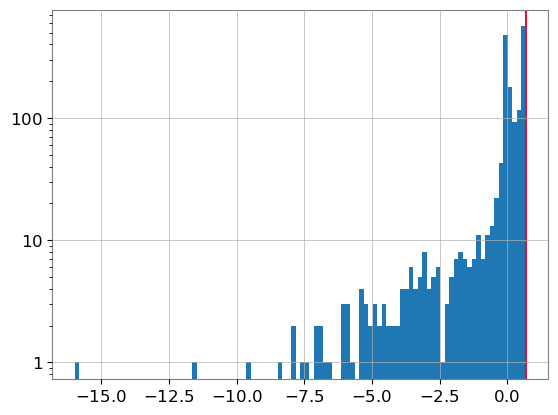

In [187]:
def amazingStat(ds1, ds2, dm1, dm2, dt, ph1, pl1, netSNR, netChisq):
    epsilon =10**(-12)
    #ams = np.log((ph1*pl1)/2*np.exp(-ds1-ds2-dm1-dm2-dt+netSNR))
    ams = np.log(pl1+ph1)
    #ams = (ph1*pl1*np.exp(-dt+netSNR-(ds1+ds2+epsilon)/2-(dm1 +dm2+epsilon)/2+netChisq))
    return ams

print(amazingStat(ds1gw, ds2gw, dm1gw, dm2gw, dtgw, ph1gw, pl1gw, netSNRgw, netChisqgw))
plt.hist(amazingStat(ds1, ds2, dm1, dm2, dt, ph1, pl1, netSNR, netChisq).values, bins=100)
plt.axvline(amazingStat(ds1gw, ds2gw, dm1gw, dm2gw, dtgw, ph1gw, pl1gw, netSNRgw, netChisqgw).values, c='crimson')
plt.yscale('log')


In [196]:
merged['SNR_L1']

0       4.141871
1       4.385252
2       4.101066
3       4.167203
4       4.094711
          ...   
1666    4.417823
1667    5.181598
1668    4.433145
1669    5.408497
1670    4.659464
Name: SNR_L1, Length: 1671, dtype: float64

In [206]:
merged

,index_H1,SNR_H1,Chisq_H1,Mass_1_H1,Mass_2_H1,Spin1z_H1,Spin2z_H1,Prob0_H1,Prob1_H1,Prob2_H1,...,Spin2z_L1,Prob0_L1,Prob1_L1,Prob2_L1,Prob3_L1,Prob4_L1,Prob5_L1,Prob6_L1,Cluster ID_L1,Cluster time_L1
0,335929.0,5.504354,1.216764,42.242497,9.939208,0.937476,0.696860,1.082480e-10,1.052800e-10,5.226650e-30,...,0.647409,0.020874,7.528163e-22,1.284175e-27,9.791264e-01,1.058950e-38,3.854459e-26,3.399623e-14,62426.0,1.242423e+09
1,335933.0,4.337716,0.571162,74.076344,8.179716,0.907492,-0.452376,9.433743e-01,3.368044e-24,0.000000e+00,...,-0.445660,1.000000,1.724178e-22,4.841650e-37,3.444925e-19,0.000000e+00,1.157837e-37,1.460092e-09,62432.0,1.242423e+09
2,335940.0,4.431832,0.779133,52.862414,5.686511,-0.918176,0.054993,7.037326e-01,6.222820e-24,1.000000e-45,...,0.054713,0.990589,1.657566e-12,4.280655e-15,9.409504e-03,5.694222e-32,0.000000e+00,1.905000e-06,62441.0,1.242423e+09
3,335942.0,4.177088,1.183540,83.740386,10.077686,0.866274,0.570191,1.884006e-01,1.057721e-24,2.333606e-38,...,0.566264,1.000000,4.360502e-15,3.470730e-31,9.291057e-09,1.405185e-27,2.504373e-27,3.362249e-07,62442.0,1.242423e+09
4,335943.0,4.242392,1.185355,73.949013,10.798553,0.979575,-0.969314,9.525005e-01,6.776906e-03,0.000000e+00,...,-0.969314,1.000000,3.190380e-32,0.000000e+00,3.749617e-18,0.000000e+00,1.380338e-27,2.347520e-11,62443.0,1.242423e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1666,340960.0,5.502688,0.870507,56.644993,6.525756,0.969895,-0.795147,6.784990e-02,4.852498e-11,1.453236e-39,...,-0.795147,1.000000,1.510665e-11,0.000000e+00,1.331121e-16,0.000000e+00,1.117761e-08,9.204244e-09,67509.0,1.242462e+09
1667,340962.0,5.178270,0.998766,47.378820,8.715445,-0.695802,-0.245646,9.997788e-01,6.090972e-07,1.066000e-42,...,-0.246502,1.000000,7.622361e-22,0.000000e+00,1.537342e-28,6.327377e-32,0.000000e+00,8.968101e-19,67513.0,1.242462e+09
1668,340964.0,5.483469,1.096538,44.125382,6.327168,0.866262,0.161709,2.577026e-01,7.243213e-13,6.172498e-27,...,0.155271,0.997979,1.006534e-25,1.060241e-23,1.638180e-12,2.266520e-40,3.329493e-04,1.688237e-03,67515.0,1.242463e+09
1669,340966.0,4.497471,1.325740,45.466864,5.293616,0.885530,-0.904661,4.592817e-01,4.598828e-06,1.317823e-31,...,-0.904601,1.000000,1.450758e-13,0.000000e+00,2.116804e-07,0.000000e+00,3.470595e-10,8.974009e-10,67517.0,1.242463e+09


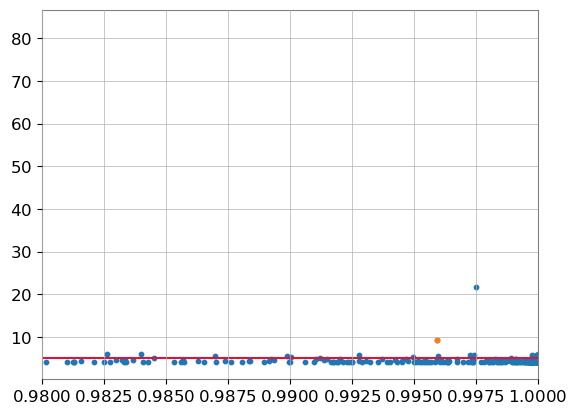

In [199]:
plt.scatter(ph1*pl1, merged['SNR_L1'], s=10)
plt.scatter(ph1gw*pl1gw, gw190521['SNR_L1'], s=10)
plt.xlim(0.98, 1)
#plt.ylim(0, 20)
plt.axhline(5, c='crimson')
#plt.xscale('log')
#plt.yscale('log')

In [1179]:
ph1gw*pl1gw

1094    0.995926
dtype: float64

(array([559.,  70.,  44.,  33.,  18.,  16.,  20.,  17.,  13.,
          8.,   9.,  13.,  10.,   6.,  11.,   3.,  12.,   8.,
          6.,   6.,   9.,   4.,   5.,   3.,   5.,   9.,   6.,
          5.,   7.,   3.,   2.,   5.,   5.,   2.,   0.,   7.,
          6.,   0.,   4.,   5.,   3.,   7.,   3.,   3.,   3.,
          8.,   1.,   6.,   5.,   1.,   4.,   1.,   6.,   3.,
          4.,   5.,   8.,   8.,   7.,   5.,   4.,   5.,  10.,
          6.,   7.,   1.,   2.,   1.,   7.,   6.,   6.,   7.,
          8.,   5.,   5.,   3.,   3.,  10.,   0.,   5.,   7.,
         10.,   8.,   8.,  10.,   7.,   5.,   9.,   4.,   3.,
          4.,   8.,  16.,  11.,  12.,  13.,  16.,  28.,  39.,
        287.]),
 array([6.81726183e-36, 1.00000000e-02, 2.00000000e-02,
        3.00000000e-02, 4.00000000e-02, 5.00000000e-02,
        6.00000000e-02, 7.00000000e-02, 8.00000000e-02,
        9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01,
        1.50000000e-01

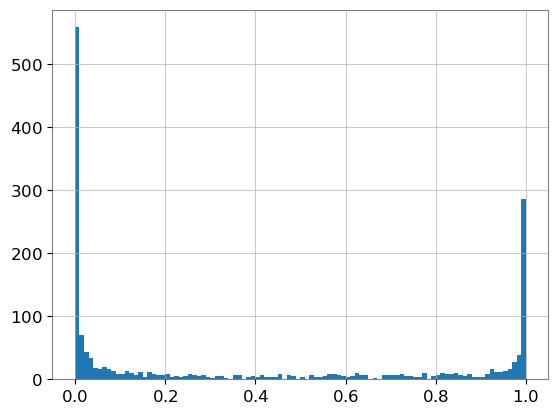

In [1174]:
plt.hist(ph1*pl1, bins=100)

In [1154]:
np.log(pl1gw*ph1gw)

1094   -0.004083
dtype: float64

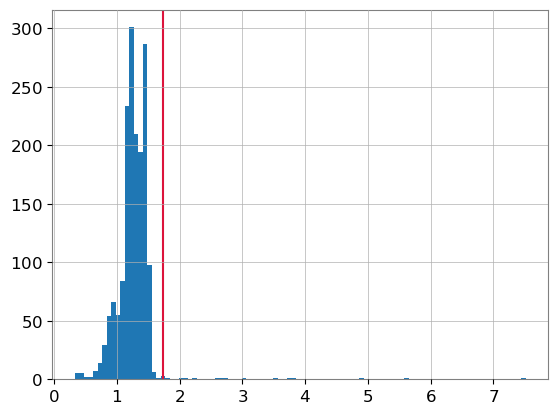

In [1141]:

plt.hist(np.log(pl1+ph1+netChisq + np.exp(-dm1-dm2-ds1-ds2)), bins=100)
plt.axvline(np.log(pl1gw+ph1gw+netChisqgw + np.exp(-dm1gw-dm2gw-ds1gw-ds2gw)).values, c='crimson')

In [1110]:
np.log(pl1gw*ph1gw + np.exp(-dm1gw-dm2gw-ds1gw-ds2gw)+netChisqgw).values, netChisqgw, netChisq[np.argmax(np.log(pl1*ph1 + np.exp(-dm1-dm2-ds1-ds2)+netChisq))]

(array([1.55001182]),
 1094    3.710678
 dtype: float64,
 1843.7926074433542)

In [1076]:
max(dm1)

400.26221254816517

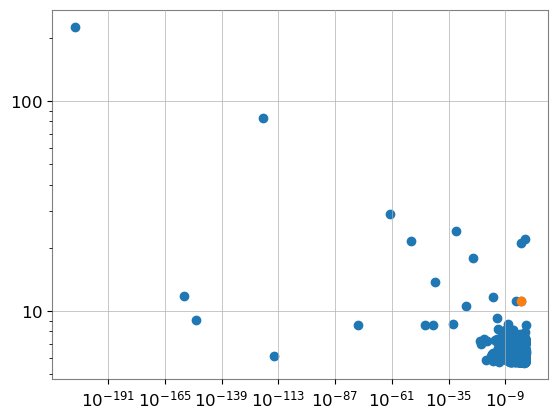

In [1070]:
plt.scatter(ph1*pl1*netChisq*np.exp(-ds1-dm1), netSNR)
plt.scatter(ph1gw*pl1gw*netChisqgw*np.exp(-ds1gw-dm1gw), netSNRgw)
plt.yscale('log')
plt.xscale('log')

In [1045]:
a = np.argmin(amazingStat(ds1, ds2, dm1, dm2, dt, ph1, pl1, netSNR, netChisq))
display(merged.iloc[[a]]['Prob0_H1'])
amazingStat(ds1, ds2, dm1, dm2, dt, ph1, pl1, netSNR, netChisq).values.sum()

667    6.817387e-36
Name: Prob0_H1, dtype: float64

480.8597926121278

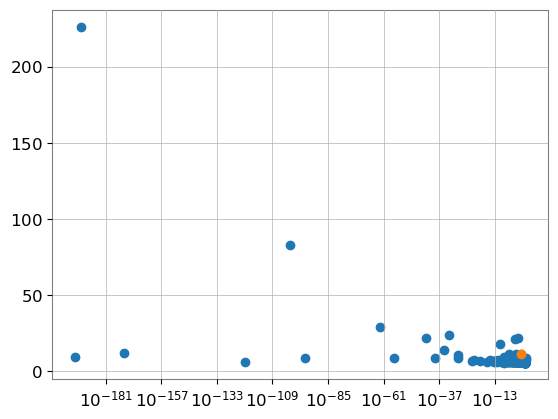

In [980]:
plt.scatter(amazingStat(ds1, ds2, dm1, dm2, dt, ph1, pl1, netSNR, netChisq), np.sqrt(merged['SNR_H1']**2+merged['SNR_L1']**2))
plt.scatter(amazingStat(ds1gw, ds2gw, dm1gw, dm2gw, dtgw, ph1gw, pl1gw, netSNRgw, netChisqgw), np.sqrt(gw190521['SNR_H1']**2+gw190521['SNR_L1']**2))
plt.xscale('log')

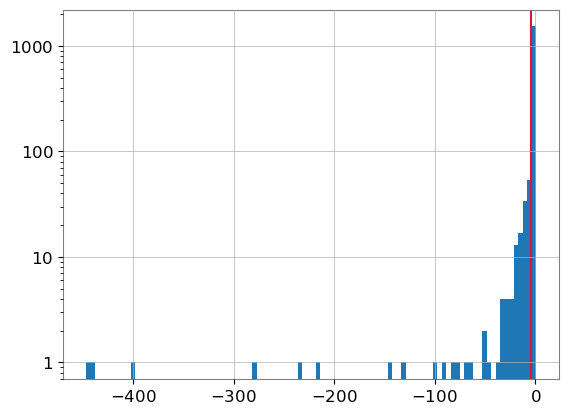

In [985]:
plt.hist(amazingStat(ds1, ds2, dm1, dm2, dt, ph1, pl1, netSNR, netChisq).values, bins=100)
plt.axvline(amazingStat(ds1gw, ds2gw, dm1gw, dm2gw, dtgw, ph1gw, pl1gw, netSNRgw, netChisqgw).values, c='crimson')
plt.yscale('log')

In [662]:
np.argmax(amazingStat(ds1, ds2, dm1, dm2, dt, ph1, pl1, netSNR))

68

In [670]:
merged.iloc[68]['Prob0_L1']

0.9839279000000001

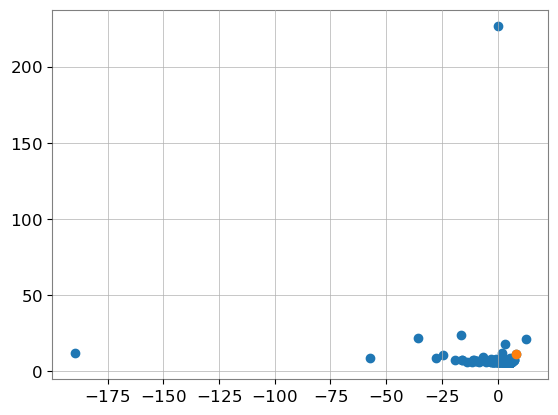

In [673]:
plt.scatter(amazingStat(ds1, ds2, dm1, dm2, dt, ph1, pl1, netSNR), np.sqrt(merged['SNR_H1']**2+merged['SNR_L1']**2))
plt.scatter(amazingStat(ds1gw, ds2gw, dm1gw, dm2gw, dtgw, ph1gw, pl1gw, netSNRgw), np.sqrt(gw190521['SNR_H1']**2+gw190521['SNR_L1']**2))
plt.

In [582]:
Th1, Tl1, As = list(), list(), list()
for i in range(10000):
    tmp_h1 = pH1.iloc[i]
    th1 = tmp_h1['Cluster time']
    tmp_l1 = pL1[(pL1['Cluster time'] > th1 -0.03) & (pL1['Cluster time'] < th1 +0.03)]
    
    if len(tmp_l1) != 0:
        tl1 = tmp_l1['Cluster time'].values[0]

        th1, tl1, stat = amazingStat2ifo(tmp_h1, tmp_l1)

        #if stat > 9:
        #    print(tmp_h1['Prob0'], tmp_l1['Prob0'].values[0])
        #    print(tmp_h1['SNR'], tmp_l1['SNR'].values[0])
        #    print(np.abs(tmp_h1['Mass_1'] - tmp_l1['Mass_1'].values[0]), np.abs(tmp_h1['Mass_2'] - tmp_l1['Mass_2'].values[0]))
        #    print(np.abs(th1-tl1))
        #    print(' ')

        #print(pH1.iloc[i]['Prob0'], ph1*pl1)
        #display(tmp_l1)

        #q_scan = QScanht(th1-2, th1+2, 'H1')
        #plot(q_scan, th1-2, th1, th1+2)

        #q_scan = QScanht(tl1-2, tl1+2, 'L1')
        #plot(q_scan, tl1-2,tl1, tl1+2)

        Th1.append(th1)
        Tl1.append(th1)
        As.append(stat)
        #if stat > 0:
        #print(th1 - tl1, stat)
        #q_scan = QScanht(th1-2, th1+2, 'H1')
        #plot(q_scan, th1-2, th1, th1+2)

        #q_scan = QScanht(tl1-2, tl1+2, 'L1')
        #plot(q_scan, tl1-2,tl1, tl1+2)
#print(th1 - tl1)

0.001 0.00013359569164780318 7.059087669686809
1.106 0.18427156 7.051156587535167
0.0 2.006096180805188e-09 6.9960879673373215
0.0 3.3910017186059696e-05 7.043981010854159
4.41 0.8091133 6.979860716461582
0.004 0.0006383971606899949 7.011331383048613
0.0 5.2249060888978005e-06 7.783322204402708
0.0 5.37759332027748e-06 7.073018141392847
0.002 0.000398969687973504 6.970954742326363
5.554 1.0 6.999373741991762
5.531 0.999730054170075 6.986651332460021
0.008 0.001544423034328944 6.980582712911048
0.0 1.2640736978564396e-08 6.9952249732368195
0.328 0.060720567 6.974622224388539
2.327 0.42798123 6.979153453961414
0.001 0.00023703258079413441 6.975404620909824
3.51 0.64219767 6.991002609009656
5.389 0.99999535 6.969934773809787
0.625 0.1157887284765909 6.972953701672525
5.443 0.9999899999999999 6.975664427686883
0.246 0.04485854 6.983221246366271
0.0 4.1209441346685004e-06 6.993283482611812
5.464 1.0 7.024403443031861
1.713 0.30211260255449995 7.012271645537434
0.0 5.48132143383552e-07 7.056

(array([1.769e+03, 7.750e+02, 2.440e+02, 6.000e+00, 2.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([ 0.        ,  2.7400914 ,  5.4801828 ,  8.2202742 ,
        10.9603656 , 13.700457  , 16.4405484 , 19.1806398 ,
        21.9207312 , 24.66082259, 27.40091399]),
 <BarContainer object of 10 artists>)

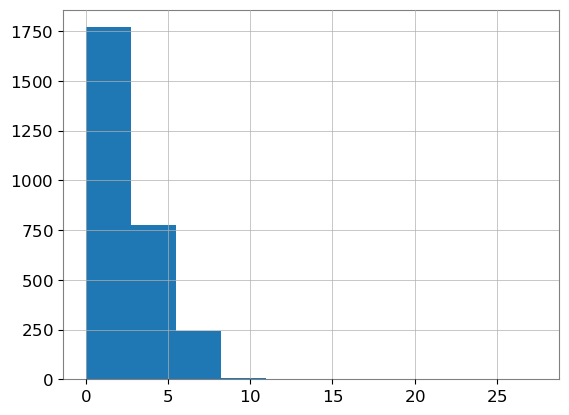

In [583]:
plt.hist(As)

In [314]:
Th1, Tl1, As = list(), list(), list()
for i in range(len(pH1_)):
    tmp_h1 = pH1_.iloc[i]
    th1 = tmp_h1['Cluster time']
    tmp_l1 = pL1_[(pL1_['Cluster time'] > th1 -0.03) & (pL1_['Cluster time'] < th1 +0.03)]
    
    if len(tmp_l1) != 0:
        tl1 = tmp_l1['Cluster time'].values[0]
        #if (np.asarray(tmp_h1['Prob0']) > 0.9) and (np.asarray(tmp_l1['Prob0'].values[0]) > 0.9):

        ph1 = tmp_h1['Prob0']
        pl1 = tmp_l1['Prob0'].values[0]
        snr_h1 = tmp_h1['SNR']
        snr_l1 = tmp_l1['SNR'].values[0]
        dt = np.abs(th1-tl1)
        dm1 = np.abs(tmp_h1['Mass_1'] - tmp_l1['Mass_1'].values[0])
        dm2 = np.abs(tmp_h1['Mass_2'] - tmp_l1['Mass_2'].values[0])
        sigma_m1 = 2
        sigma_m2 = 2

        th1, tl1, stat = amazingStat2ifo(tmp_h1, tmp_l1)
        #if stat < -50:
        print(th1 - tl1, stat)
        #q_scan = QScanht(th1-2, th1+2, 'H1')
        #plot(q_scan, th1-2, th1, th1+2)

        #q_scan = QScanht(tl1-2, tl1+2, 'L1')
        #plot(q_scan, tl1-2,tl1, tl1+2)
#print(th1 - tl1)

0.004671573638916016 14.031123220302002
-0.014748096466064453 0.20429474946280152
-0.008308172225952148 11.811773165374063
0.0068318843841552734 57.05729832339619
0.024204015731811523 17.556157973161397


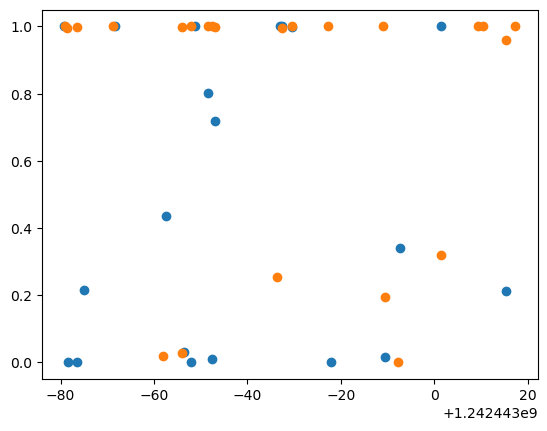

In [135]:
plt.scatter(tH1['Cluster ID'], dH1['Probability'])
plt.scatter(tL1['Cluster ID'], dL1['Probability'])

In [96]:
ytestH1, ltestH1 = predictions(dH1, modelH1)
ytestL1, ltestL1 = predictions(dL1, modelL1)

(20, 6) (20,)
(23, 6) (23,)


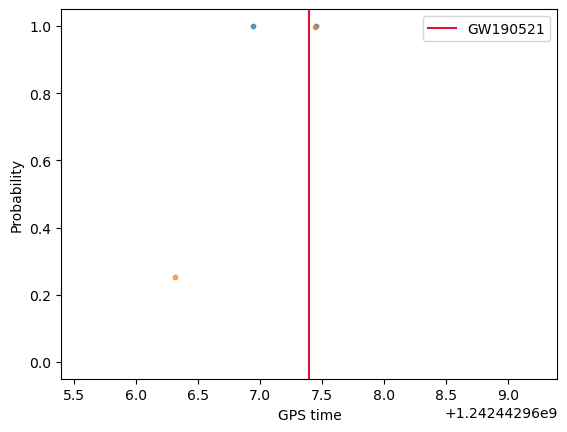

In [107]:
plt.scatter(tH1['Cluster ID'], ytestH1[:, 0], s=10,alpha=0.7)
plt.scatter(tL1['Cluster ID'], ytestL1[:, 0], s=10,alpha=0.7)
plt.axvline(1242442967.4, c='crimson', label='GW190521')
plt.xlim(1242442967.4-2, 1242442967.4+2)
plt.ylabel('Probability')
plt.xlabel('GPS time')
plt.legend()

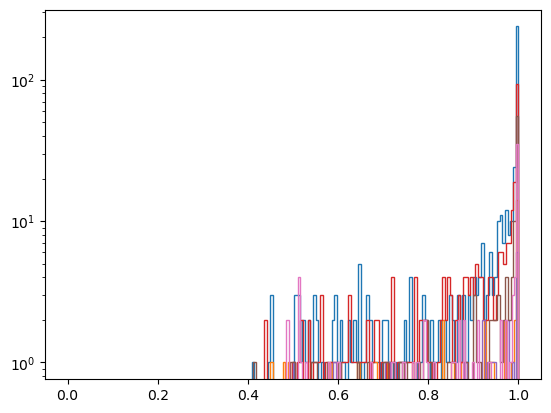

In [53]:
for i in range(7):
    plt.hist(y_pred[np.where(pred_labels == i)][:, i].detach().numpy(), histtype ='step', bins =100)
plt.yscale('log')
plt.

### O3b analysis

*Class tags*

```
if 'Injections' in file_name: t = 0

if 'Blip' in file_name: t = 1

if 'Koi_Fish' in file_name: t = 2

if 'Low_Frequency_Burst' in file_name: t = 3

if 'Tomte' in file_name: t = 4

if 'Whistle' in file_name: t = 5

if 'Fast_Scattering' in file_name:t = 6
```

In [27]:
path = '../output_new/tw'+str(tw)+'/predictions/'
file = 'pred_known_'+ifo+'_'+run+'.csv'
tmp = pd.read_csv(path + file)
tmp = tmp.loc[:, ~tmp.columns.str.match('Unnamed')]
tmp.columns
pred_labels = tmp.to_numpy()
pred_labels = pred_labels[:, 7:]

Index(['SNR', 'Chisq', 'Mass_1', 'Mass_2', 'Spin1z', 'Spin2z', 'Class',
       'Num_triggers', 'Prob0', 'Prob1', 'Prob2', 'Prob3', 'Prob4', 'Prob5',
       'Prob6'],
      dtype='object')

In [3]:
from textwrap import wrap

(7, 7)
98.75
(7, 7)
95.81
(6, 6)
99.27
(7, 7)
73.01
(7, 7)
67.45
(6, 6)
75.91


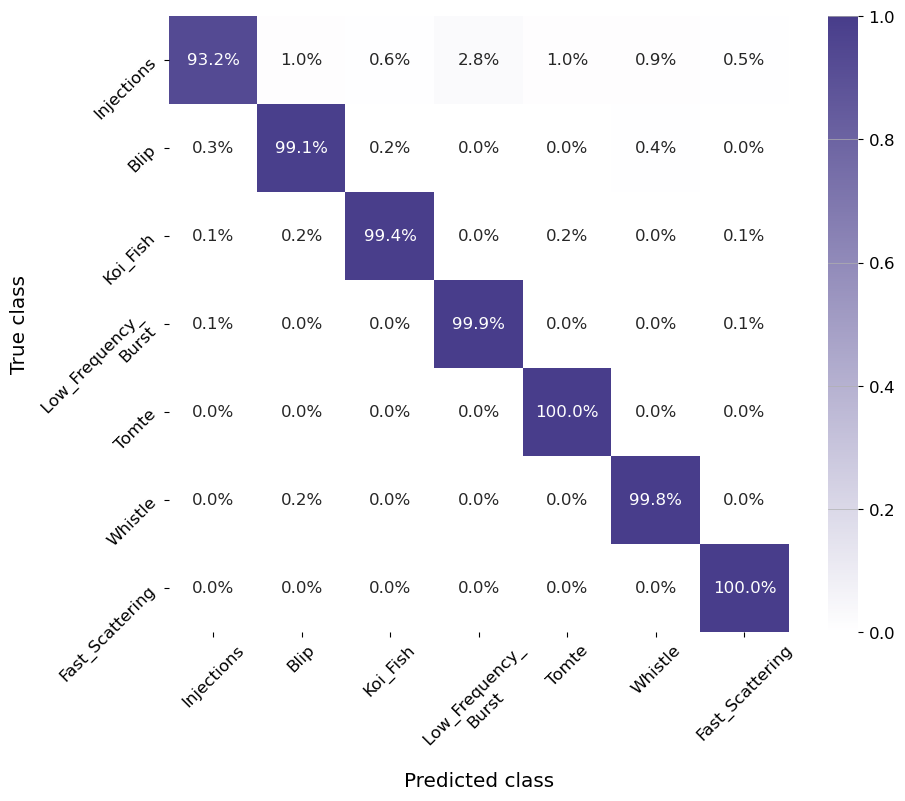

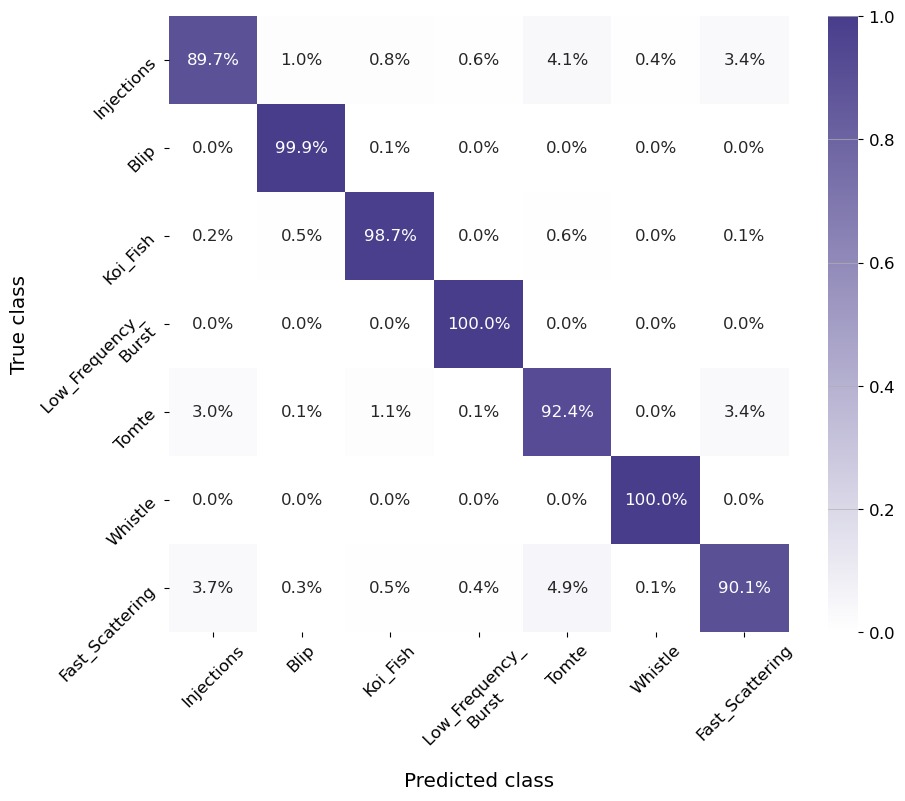

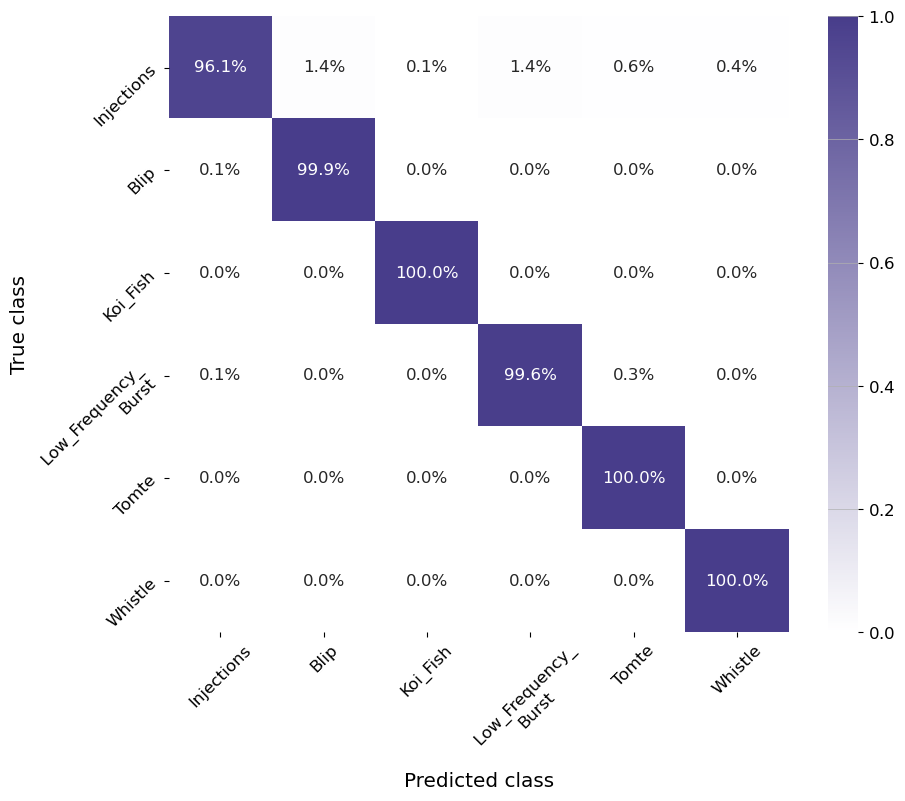

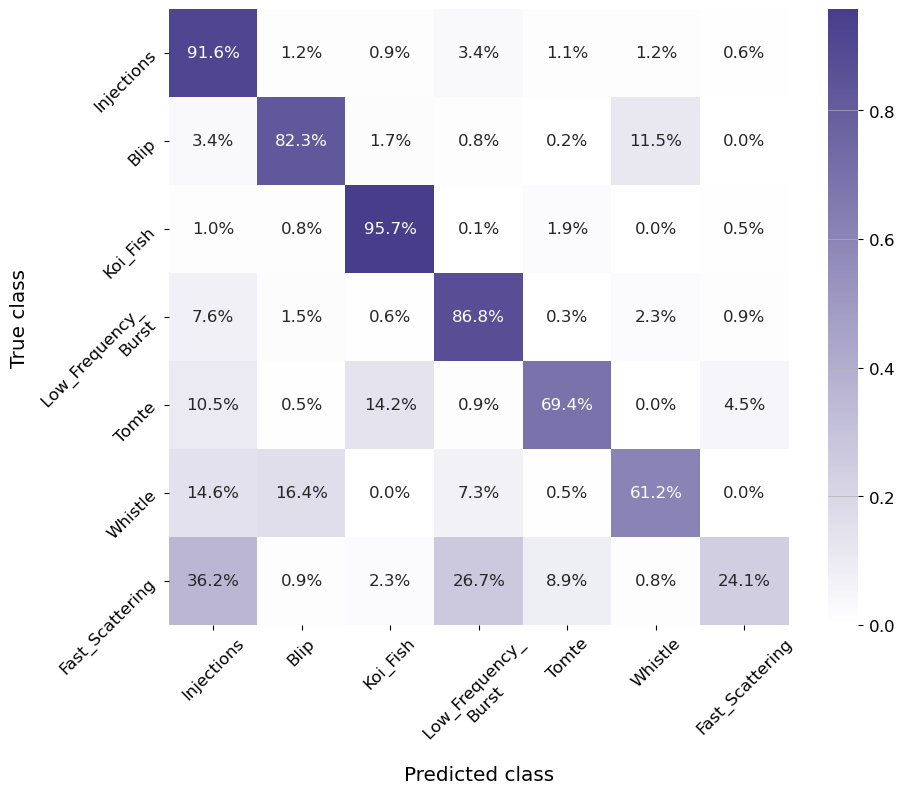

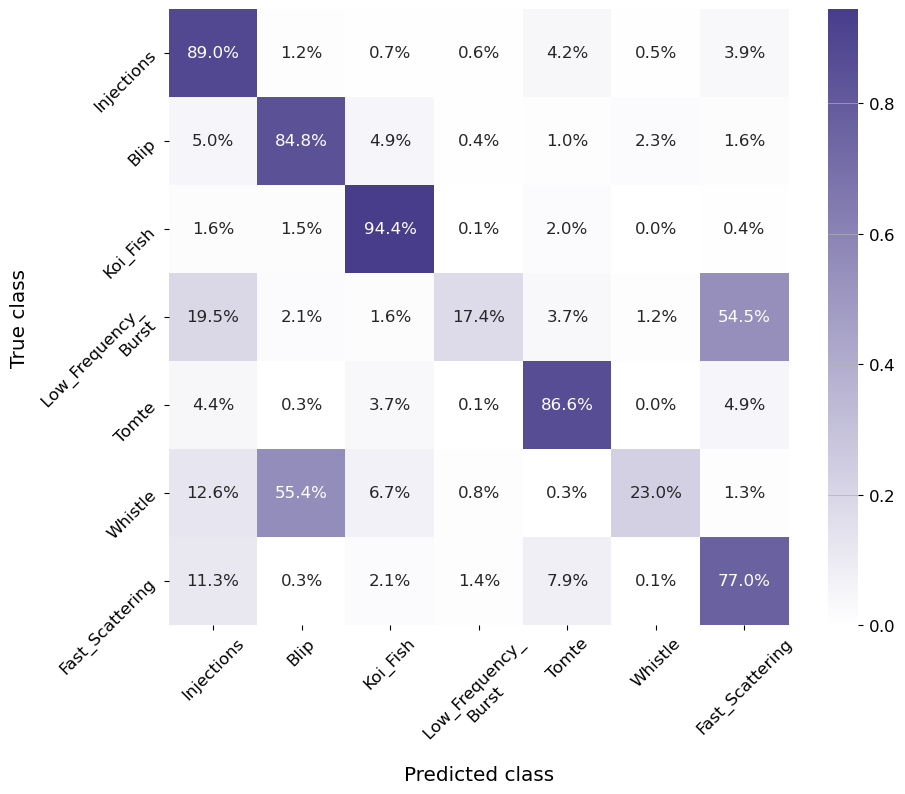

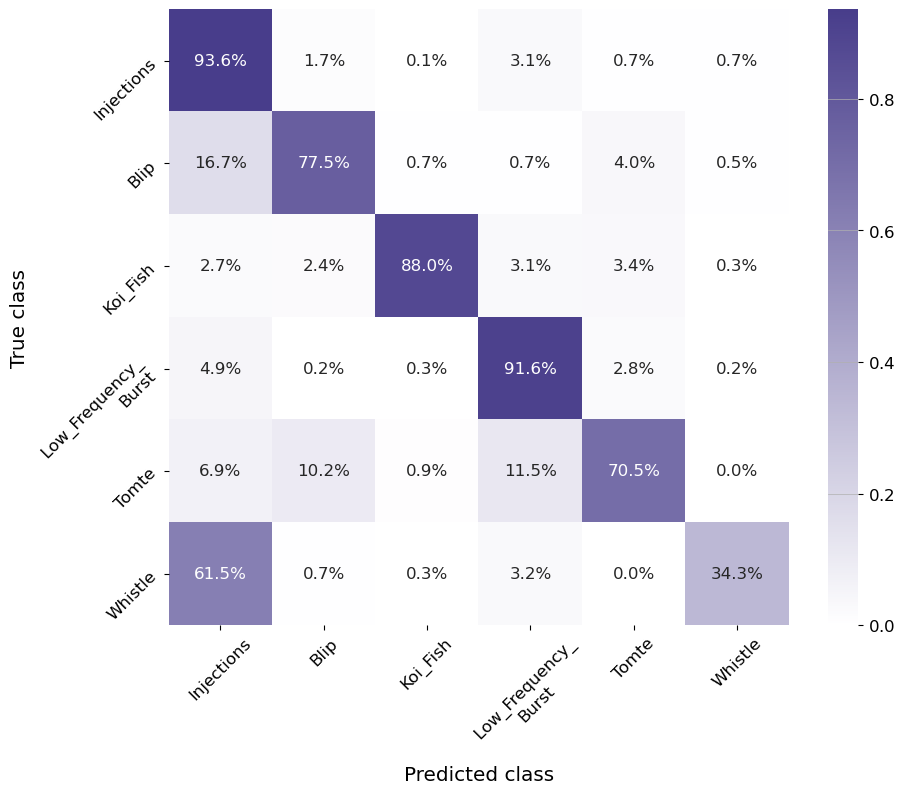

In [4]:
cmap = LinearSegmentedColormap.from_list(
        name='test', 
        colors=['white', 'darkslateblue'])
tw, ifo, run = 0.05, 'V1', 'O3b'
for run in ['O3a', 'O3b']:
    for ifo in ['H1', 'L1', 'V1']:
        for tw in [0.05]:
            path = '../output_new/tw'+str(tw)+'/predictions/'
            file = 'pred_known_'+ifo+'_'+run+'.csv'
            tmp = pd.read_csv(path + file)
            tmp = tmp.loc[:, ~tmp.columns.str.match('Unnamed')]

            pred_labels = tmp.to_numpy()
            pred_labels = pred_labels[:, 8:]
            pred_labels = np.argmax(pred_labels, axis=1)
            true_labels = tmp['Class'].to_numpy()

            cfm = confusion_matrix(true_labels, pred_labels)
            print(cfm.shape)
            tmp = 0
            for i in range(cfm.shape[0]):
                tmp = cfm[i][i] + tmp
            print(np.round(tmp / cfm.sum()*100, 2))
            cfm = np.round(cfm/np.sum(cfm, axis=1), 3)

            classes = ['Injections', 'Blip', 'Koi_Fish', ' Low_Frequency_Burst',
                       'Tomte', 'Whistle', 'Fast_Scattering']
            classes = ['\n'.join(wrap(x, 15)) for x in classes] 
            if ifo == 'V1':
                classes = classes[:-1]
            fig = plt.figure(figsize=(10, 8), dpi=100)
            sns.heatmap(cfm, annot=True, fmt=".1%", cmap=cmap)
            plt.xticks(np.arange(len(classes))+0.5, classes, rotation=45)
            plt.yticks(np.arange(len(classes))+0.5, classes, rotation=45)
            plt.xlabel('Predicted class')
            plt.ylabel('True class')
            plt.grid(False)
            #plt.title('tw='+str(tw))
            plt.savefig('/data/gravwav/lopezm/Projects/GlitchBank/gifs/'+ifo+'/cfm_'+str(tw)+'_'+run+'.pdf',
                        format="pdf", bbox_inches="tight", rasterized=True)
            #plt.savefig('/data/gravwav/lopezm/Projects/GlitchBank/gifs/'+ifo+'/cfm_'+str(tw)+'_'+run+'.png')


In [44]:
tmp2 = tmp.loc[tmp['Class'] == 2]

Text(0, 0.5, 'Counts')

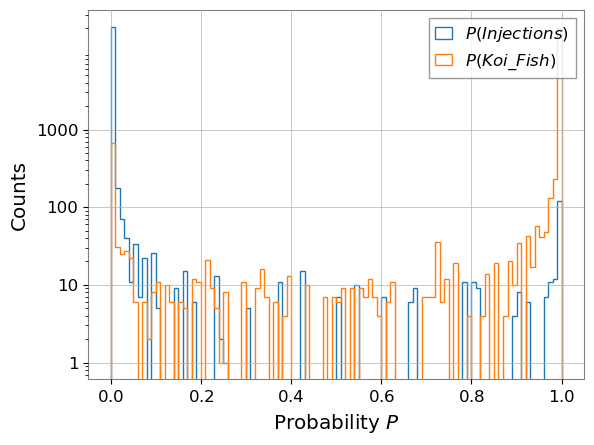

In [61]:
plt.hist(tmp2['Prob0'], density=False, bins=100,
         histtype='step', label=r'$P(Injections)$')
plt.hist(tmp2['Prob2'], density=False, bins=100,
         histtype='step', label=r'$P(Koi\_Fish)$')
plt.legend()
plt.yscale('log')
plt.yticks([1, 10, 100, 1000], [1, 10, 100, 1000])
plt.xlabel(r'Probability $P$')
plt.ylabel('Counts')

array([2., 4., 1., ..., 6., 6., 1.])

In [85]:
cfm = confusion_matrix(true_labels, pred_labels)
cfm = np.round(cfm/np.sum(cfm, axis=1), 2)

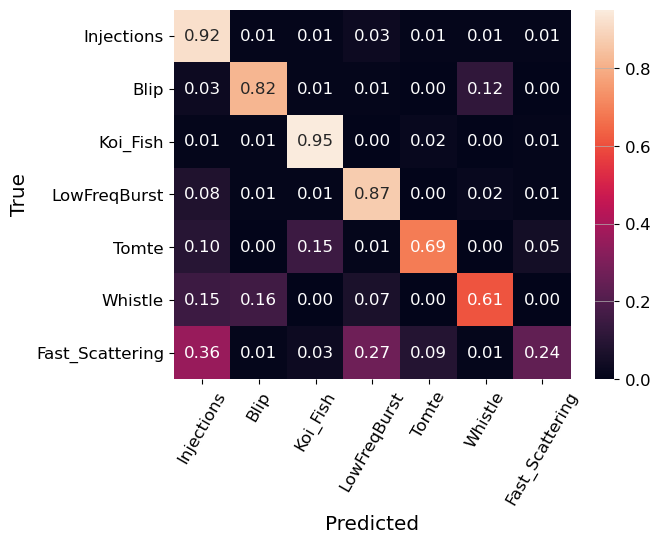

In [127]:
import os
from PIL import Image, ImageFont, ImageDraw

In [151]:
tw = 0.05
font = ImageFont.truetype("/data/gravwav/lopezm/Projects/GlitchBank/arial.ttf",25)

for ifo in ['H1', 'L1', 'V1']:
    for tw in [0.05, 0.1, 0.2, 0.5]:
        path = '/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/output_new/tw'+str(tw)+'/results/'
        for file in os.listdir(path):
            if ifo in file and file.endswith('png'):
                os.system('cp '+path+file+' /data/gravwav/lopezm/Projects/GlitchBank/gifs/'+ifo+'/cfm_'+str(tw)+'_O3a.png')
                i=Image.open('/data/gravwav/lopezm/Projects/GlitchBank/gifs/'+ifo+'/cfm_'+str(tw)+'_O3a.png')
                Im = ImageDraw.Draw(i)
                Im.text((475, 50), r"tw="+str(tw),fill=(0, 0, 0), font=font)
                i.save('/data/gravwav/lopezm/Projects/GlitchBank/gifs/'+ifo+'/cfm_'+str(tw)+'_O3a.png')

In [167]:
import glob
from PIL import Image
def make_gif(frame_folder, name):
    frames = [Image.open(image) for image in glob.glob(f"{frame_folder}/*O3b*.png")]
    frame_one = frames[0]
    frame_one.save(name, format="GIF", append_images=frames,
               save_all=True, duration=1000, loop=0)

for ifo in ['H1', 'L1', 'V1']:
    make_gif("/data/gravwav/lopezm/Projects/GlitchBank/gifs/"+ifo,
             '/data/gravwav/lopezm/Projects/GlitchBank/gifs/'+ifo+'/cfm_'+ifo+'_O3b.gif')

### Generate coincident CSVS

In [ ]:
for ifos in ['H1L1', 'L1V1', 'H1V1', 'H1L1V1']:
    for tw in [0.05, 0.1, 0.2, 0.5]:
        f = open("../../coinc_runs/run_"+ifos+"_"+str(tw)+".sh", "a")
        f.write("#!/usr/bin/bash"+ os.linesep +
        "source ~/.bashrc" + os.linesep +
        "conda activate /data/gravwav/lopezm/cmb_env/miniforge3/envs/ml_course"+ os.linesep +
        "python3 /data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/src/unknown_coinc.py --tw="+str(tw)+" --ifos="+ifos)
        f.close()